In [1]:
import requests
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

url = "https://dummyjson.com/products"

response = requests.get(url)

print(response.status_code)

200


In [2]:
data = response.json()
print(type(data))

<class 'dict'>


In [3]:
print(data.keys())

dict_keys(['products', 'total', 'skip', 'limit'])


In [4]:
print(data["products"][0])

{'id': 1, 'title': 'Essence Mascara Lash Princess', 'description': 'The Essence Mascara Lash Princess is a popular mascara known for its volumizing and lengthening effects. Achieve dramatic lashes with this long-lasting and cruelty-free formula.', 'category': 'beauty', 'price': 9.99, 'discountPercentage': 10.48, 'rating': 2.56, 'stock': 99, 'tags': ['beauty', 'mascara'], 'brand': 'Essence', 'sku': 'BEA-ESS-ESS-001', 'weight': 4, 'dimensions': {'width': 15.14, 'height': 13.08, 'depth': 22.99}, 'warrantyInformation': '1 week warranty', 'shippingInformation': 'Ships in 3-5 business days', 'availabilityStatus': 'In Stock', 'reviews': [{'rating': 3, 'comment': 'Would not recommend!', 'date': '2025-04-30T09:41:02.053Z', 'reviewerName': 'Eleanor Collins', 'reviewerEmail': 'eleanor.collins@x.dummyjson.com'}, {'rating': 4, 'comment': 'Very satisfied!', 'date': '2025-04-30T09:41:02.053Z', 'reviewerName': 'Lucas Gordon', 'reviewerEmail': 'lucas.gordon@x.dummyjson.com'}, {'rating': 5, 'comment': '

In [5]:
print(len(data["products"]))

30


In [6]:
print("Products received:", len(data["products"]))
print("Total products:", data["total"])
print("Limit:", data["limit"])
print("Skip:", data["skip"])

Products received: 30
Total products: 194
Limit: 30
Skip: 0


In [7]:
all_products = []

limit = 30
skip = 0

while skip < data["total"]:
    response = requests.get(
        f"https://dummyjson.com/products?limit={limit}&skip={skip}"
    )
    
    page_data = response.json()
    
    all_products.extend(page_data["products"])
    
    skip += limit

print("Total products collected:", len(all_products))

Total products collected: 194


In [8]:
print(type("all_products"))
print(len(all_products))
print(all_products[0]["title"])
print(all_products[-1]["title"])

<class 'str'>
194
Essence Mascara Lash Princess
Women's Wrist Watch


In [9]:
print(type("all_products"))
print(all_products[:2])

<class 'str'>
[{'id': 1, 'title': 'Essence Mascara Lash Princess', 'description': 'The Essence Mascara Lash Princess is a popular mascara known for its volumizing and lengthening effects. Achieve dramatic lashes with this long-lasting and cruelty-free formula.', 'category': 'beauty', 'price': 9.99, 'discountPercentage': 10.48, 'rating': 2.56, 'stock': 99, 'tags': ['beauty', 'mascara'], 'brand': 'Essence', 'sku': 'BEA-ESS-ESS-001', 'weight': 4, 'dimensions': {'width': 15.14, 'height': 13.08, 'depth': 22.99}, 'warrantyInformation': '1 week warranty', 'shippingInformation': 'Ships in 3-5 business days', 'availabilityStatus': 'In Stock', 'reviews': [{'rating': 3, 'comment': 'Would not recommend!', 'date': '2025-04-30T09:41:02.053Z', 'reviewerName': 'Eleanor Collins', 'reviewerEmail': 'eleanor.collins@x.dummyjson.com'}, {'rating': 4, 'comment': 'Very satisfied!', 'date': '2025-04-30T09:41:02.053Z', 'reviewerName': 'Lucas Gordon', 'reviewerEmail': 'lucas.gordon@x.dummyjson.com'}, {'rating': 

In [10]:
print(type(all_products))
print(type(all_products)[0])
print(len(all_products))

<class 'list'>
list[0]
194


In [11]:
df = pd.DataFrame(all_products)

In [12]:
print(df.shape)
print(df.columns)

(194, 22)
Index(['id', 'title', 'description', 'category', 'price', 'discountPercentage',
       'rating', 'stock', 'tags', 'brand', 'sku', 'weight', 'dimensions',
       'warrantyInformation', 'shippingInformation', 'availabilityStatus',
       'reviews', 'returnPolicy', 'minimumOrderQuantity', 'meta', 'images',
       'thumbnail'],
      dtype='str')


In [13]:
df.dtypes

id                        int64
title                       str
description                 str
category                    str
price                   float64
discountPercentage      float64
rating                  float64
stock                     int64
tags                     object
brand                       str
sku                         str
weight                    int64
dimensions               object
warrantyInformation         str
shippingInformation         str
availabilityStatus          str
reviews                  object
returnPolicy                str
minimumOrderQuantity      int64
meta                     object
images                   object
thumbnail                   str
dtype: object

In [14]:
df.isnull().sum()

id                       0
title                    0
description              0
category                 0
price                    0
discountPercentage       0
rating                   0
stock                    0
tags                     0
brand                   92
sku                      0
weight                   0
dimensions               0
warrantyInformation      0
shippingInformation      0
availabilityStatus       0
reviews                  0
returnPolicy             0
minimumOrderQuantity     0
meta                     0
images                   0
thumbnail                0
dtype: int64

In [15]:
print("Duplicate rows:", df.duplicated().sum())

TypeError: unhashable type: 'list'

In [ ]:
print("Duplicate product IDs:", df["id"].duplicated().sum())

In [ ]:
print(
    "Duplicate product records:",
    df.duplicated(
        subset=["title", "category", "price", "brand"]
    ).sum()
)

In [ ]:
print("Duplicate product titles:", df["title"].duplicated().sum())

In [ ]:
df[df["title"].duplicated(keep=False)][["id", "title", "category", "price", "brand"]]

In [ ]:
print(
    "Duplicate title + category:",
    df.duplicated(
        subset=["title", "category"]
    ).sum()
)

In [ ]:
df[df["brand"].isnull()]["category"].value_counts()

In [ ]:
df[
    (df["category"] == "kitchen-accessories") &
    (df["brand"].isnull())
][["id", "title", "category", "price", "rating", "stock"]]

In [ ]:
category_brand_analysis = df.groupby("category").agg(
    total_products=("id", "count"),
    missing_brand=("brand", lambda x: x.isnull().sum())
)

category_brand_analysis["missing_percentage"] = (
    category_brand_analysis["missing_brand"]
    / category_brand_analysis["total_products"]
    * 100
)

category_brand_analysis.sort_values(
    "missing_percentage",
    ascending=False
)

In [ ]:
for product in all_products:
    if product["category"] == "kitchen-accessories":
        print(product)
        break

In [ ]:
for product in all_products:
    if product["category"] == "groceries":
        print(product)
        break

In [ ]:
for product in all_products:
    if product["category"] == "sports-accessories":
        print(product)
        break

In [ ]:
for product in all_products:
    if product["category"] == "home-decoration":
        print(product)
        break

In [ ]:
for product in all_products:
    if product["category"] == "tops":
        print(product)
        break

In [ ]:
for product in all_products:
    if product["category"] == "womens-dresses":
        print(product)
        break

In [ ]:
for product in all_products:
    if product["category"] == "womens-jewellery":
        print(product)
        break

In [ ]:
missing_brand_products = [
    product for product in all_products
    if "brand" not in product
]

print("Products without brand field:", len(missing_brand_products))

In [ ]:
categories = [
    "kitchen-accessories",
    "groceries",
    "sports-accessories",
    "home-decoration",
    "tops",
    "womens-dresses",
    "womens-jewellery"
]

for category in categories:
    for product in all_products:
        if product["category"] == category:
            print(category, "->", "brand" in product)
            break

In [ ]:
for product in all_products:
    if product["category"] == "kitchen-accessories":
        print("Kitchen:", product.keys())
        break


for product in all_products:
    if product["category"] == "beauty":
        print("Beauty", product.keys())
        break

In [ ]:
for product in all_products:
    if product["category"] == "kitchen-accessories":
        print("Title", product["title"])
        print("SKU:", product["sku"])
        break

In [ ]:
for product in all_products:
    if product["category"] == "kitchen-accessories":
        print(product["sku"])

In [ ]:
for product in all_products:
    if product["category"] == "beauty":
        print("Title:", product["title"])
        print("Brand:", product["brand"])
        print("SKU:", product["sku"])
        break

In [ ]:
brd_sku_products = [
    product for product in all_products
    if "BRD" in product["sku"]
]

print("Products with BRD in SKU:", len(brd_sku_products))

In [ ]:
print(Counter(
    product["category"]
    for product in brd_sku_products
))

In [ ]:
for product in all_products:
    if product["category"] == "kitchen-accessories":
        print(product["title"], "->", product["sku"])

In [ ]:
for product in all_products:
    if product["category"] == "kitchen-accessories":
        sku_parts = product["sku"].split("-")
        
        print(
            product["title"],
            "->",
            "Code:", sku_parts[2]
        )

In [ ]:
for product in all_products:
    if product["brand"] is not None:
        print(
            product["title"],
            "-> Brand:", product["brand"],
            "-> SKU:", product["sku"]
        )
        break

In [ ]:
count = 0

for product in all_products:
    if product["brand"] is not None:
        print(
            product["title"],
            "-> Brand:", product["brand"],
            "-> SKU:", product["sku"]
        )
        
        count += 1
        
        if count == 5:
            break

In [ ]:
for product in all_products:
    brand = product.get("brand")

    if brand is not None:
        sku_parts = product["sku"].split("-")

        print(
            "Brand:", brand,
            "-> SKU Brand Code:", sku_parts[1]
        )

In [ ]:
for product in all_products:
    if product.get("brand") is None:
        sku_parts = product["sku"].split("-")
        
        print(
            "Title:", product["title"],
            "-> Product Code:", sku_parts[2]
        )

In [ ]:
first_word_matches = []
second_word_matches = []
no_matches = []

for product in all_products:
    if product.get("brand") is None:
        title_words = product["title"].split()
        product_code = product["sku"].split("-")[2].upper()

        first_word_code = title_words[0][:3].upper()

        if product_code == first_word_code:
            first_word_matches.append(product["title"])

        elif len(title_words) > 1 and product_code == title_words[1][:3].upper():
            second_word_matches.append(product["title"])

        else:
            no_matches.append(product["title"])

print("First-word matches:", len(first_word_matches))
print("Second-word matches:", len(second_word_matches))
print("No direct matches:", len(no_matches))

In [ ]:
for product in all_products:
    if product["title"] == "Pan":
        print(product)

In [ ]:
for product in all_products:
    if product["sku"].split("-")[2] == "PRD":
        print(
            "ID:", product["id"],
            "| Title:", product["title"],
            "| Category:", product["category"],
            "| SKU:", product["sku"]
        )

In [ ]:
brd_count = 0
not_brd = []

for product in all_products:
    if product.get("brand") is None:
        sku_brand_code = product["sku"].split("-")[1]

        if sku_brand_code == "BRD":
            brd_count += 1
        else:
            not_brd.append(product["sku"])

print("Missing-brand products:", brd_count + len(not_brd))
print("BRD code:", brd_count)
print("Not BRD:", len(not_brd))
print("Not BRD SKUs:", not_brd)

In [ ]:
for product in all_products:
    if product["category"] == "groceries" and product.get("brand") is None:
        print(product["title"], "->", product["sku"])

In [ ]:
for product in all_products:
    if product["category"] == "home-decoration" and product.get("brand") is None:
        print(product["title"],  "->", product["sku"])

In [ ]:
for product in all_products:
    if product["category"] == "sports-accessories" and product.get("brand") is None:
        print(product["title"], "->", product["sku"])

In [ ]:
for product in all_products:
    if product["category"] == "tops" and product.get("brand") is None:
        print(product["title"], "->", product["sku"])

In [ ]:
for product in all_products:
    if product["category"] == "womens-dresses" and product.get("brand") is None:
        print(product["title"], "->", product["sku"])

In [ ]:
for product in all_products:
    if product["category"] == "womens-jewellery" and product.get("brand") is None:
        print(product["title"], "->", product["sku"])

In [ ]:
for product in all_products:
    if product.get("brand") is not None:
        sku_brand_code = product["sku"].split("-")[1]

        print(
             product["title"],
            "-> Brand:", product["brand"],
            "| Brand Code:", sku_brand_code,
            "| SKU:", product["sku"]
        )

In [ ]:
for product in all_products:
    if product.get("brand") is not None:

        actual_brand = product["brand"]
        sku_brand_code = product["sku"].split("-")[1]

        expected_code = actual_brand[:3].upper()

        print(
            actual_brand,
            "→ Expected:", expected_code,
            "| SKU Code:", sku_brand_code,
            "| Match:", expected_code == sku_brand_code
        )

In [ ]:
missing_brand = df[df["brand"].isnull()]

for _, row in missing_brand.iterrows():
    print(
        "Title:", row["title"],
        "| Category:", row["category"],
        "| SKU:", row["sku"]
    )

In [ ]:
missing_brand = df[df["brand"].isnull()]

for _, row in missing_brand.iterrows():
    print(
        "Title:", row["title"],
        "| Description:", row["description"]
    )
    

In [ ]:
for product in all_products:
    if product.get("brand") is None:
        print(
            "Title:", product["title"],
            "| Description:", product["description"],
            "| Brand:", product.get("brand")
        )

In [ ]:
brand_missing_by_category = (
    df[df["brand"].isna() | (df["brand"] == "No Brand")]
    .groupby("category")
    .size()
    .reset_index(name="missing_brand_count")
    .sort_values("missing_brand_count", ascending=False)
)

brand_missing_by_category

In [ ]:
df.columns.tolist()

In [ ]:
missing_brand_products = df[
    df["brand"].isna() | (df["brand"] == "No Brand")
    ][["title", "description", "brand", "category"]]

missing_brand_products.head(20)

In [ ]:
brand_missing_analysis = (
    df.assign(
        brand_missing=df["brand"].isna() | (df["brand"] == "No Brand")
    )
    .groupby("category")
    .agg(
        total_products=("brand", "size"),
        missing_brand=("brand_missing", "sum")
    )
    .reset_index()
)

brand_missing_analysis["missing_brand_percentage"] = (
    brand_missing_analysis["missing_brand"]
    / brand_missing_analysis["total_products"]
    * 100
).round(2)

brand_missing_analysis.sort_values(
    "missing_brand",
    ascending=False
)

In [ ]:
df.groupby("category")["brand"].apply(
    lambda x: x.notna().sum()
)

In [ ]:
missing_brand = df[df["brand"].isna()]
missing_brand[["id", "title", "tags"]].head(20)

In [ ]:
missing_brand = df[df["brand"].isna()]
missing_brand[["id", "title", "tags"]].iloc[20:]

In [ ]:
missing_brand = df[df["brand"].isna()]
missing_brand["tags"].isna().sum()

In [ ]:
missing_brand["sku"].isna().sum()

In [ ]:
missing_brand["weight"].isna().sum()

In [ ]:
missing_brand["dimensions"].isna().sum()

In [ ]:
missing_brand["warrantyInformation"].isna().sum()

In [ ]:
missing_brand["shippingInformation"].isna().sum()

In [ ]:
missing_brand["availabilityStatus"].isna().sum()

In [ ]:
missing_brand["returnPolicy"].isna().sum()

In [ ]:
missing_brand["minimumOrderQuantity"].isna().sum()

In [ ]:
missing_brand["reviews"].isna().sum()

In [ ]:
missing_brand.isna().sum()

In [ ]:
missing_brand["title"].nunique()

In [ ]:
missing_brand["description"].nunique()

In [ ]:
missing_brand.nunique()

In [ ]:
simple_columns = [
    "id",
    "title",
    "description",
    "category",
    "price",
    "discountPercentage",
    "rating",
    "stock",
    "brand",
    "sku",
    "weight",
    "warrantyInformation",
    "shippingInformation",
    "availabilityStatus",
    "returnPolicy",
    "minimumOrderQuantity"
]

missing_brand[simple_columns].nunique()

In [ ]:
missing_brand[["title", "description", "tags"]].head(20)

In [ ]:
missing_brand[["id", "title", "brand"]].to_string(index=False)

In [ ]:
missing_brand[["id", "title", "tags"]].to_string(index=False)

In [ ]:
missing_brand[["id", "title", "meta"]].to_string(index=False)

In [ ]:
missing_brand[["id", "title", "reviews"]].to_string(index=False)

In [ ]:
missing_brand["reviews"].apply(len).value_counts()

In [ ]:
missing_brand[["id", "title", "reviews"]].head(3).to_string(index=False)

In [ ]:
missing_brand.iloc[0]["reviews"]

In [ ]:
brand_category_check = df.groupby("category").agg(
    total_products=("id", "count"),
    missing_brand=("brand", lambda x: x.isna().sum())
)

brand_category_check["missing_brand_percentage"] = (
    brand_category_check["missing_brand"]
    / brand_category_check["total_products"]
    * 100
)

brand_category_check.sort_values(
    "missing_brand_percentage",
    ascending=False
)

In [ ]:
missing_brand[["id", "title", "category"]].head(1)

In [ ]:
product_id = 16
url = f"https://dummyjson.com/products/{product_id}"
response.json()

In [ ]:
df.groupby("category")["brand"].apply(lambda x: x.notna().sum()).sort_values()

In [ ]:
data = response.json()

response = requests.get("https://dummyjson.com/products")

products = response.json()["products"]

products[:2]

In [ ]:
brand_key_status = [
    {
        "id" : product["id"],
        "category": product["category"],
        "brand_key_present": "brand" in product
    }
    for product in products
]

brand_key_status[:10]

In [ ]:
missing_ids = set(missing_brand["id"])

missing_brand_source = [
    {
        "id": product["id"],
        "category": product["category"],
        "brand_key_present": "brand" in product
    }
    for product in products
    if product["id"] in missing_ids
]

missing_brand_source[:10]

In [ ]:
Counter(
    item["brand_key_present"]
    for item in missing_brand_source
)

In [ ]:
len(products)

In [ ]:
response = requests.get("https://dummyjson.com/products?limit=0")

products = response.json()["products"]

len(products)

In [ ]:
missing_brand_source = [
    {
        "id": product["id"],
        "category": product["category"],
        "brand_key_present": "brand" in product
    }
    for product in products
    if product["id"] in missing_ids
]

len(missing_brand_source)

In [ ]:
brand_key_check = [
    {
        "id": product["id"],
        "category": product["category"],
        "brand_key_present": "brand" in product
    }
    for product in products
    if product["id"] in missing_ids
]

len(brand_key_check)

In [ ]:
from collections import Counter

Counter(
    item["brand_key_present"]
    for item in brand_key_check
)

In [ ]:
missing_brand["brand"].isna().sum()

In [ ]:
missing_brand["brand"] = missing_brand["brand"].fillna("Unknown")

In [ ]:
missing_brand["brand"].value_counts(dropna=False)

In [ ]:
df["id"].duplicated().sum()

In [ ]:
duplicate_check_cols = [
    "title",
    "description",
    "category",
    "price",
    "discountPercentage",
    "rating",
    "stock",
    "brand",
    "sku"
]

df.duplicated(subset=duplicate_check_cols).sum()

In [ ]:
df["rating"].describe()

In [ ]:
df["price"].describe()

In [ ]:
df["discountPercentage"].describe()

In [ ]:
df["stock"].describe()

In [ ]:
df["minimumOrderQuantity"].describe()

In [ ]:
df["availabilityStatus"].describe()

In [ ]:
df["availabilityStatus"].value_counts(dropna=False)

In [ ]:
category_counts = df["category"].value_counts()
category_counts

In [ ]:
category_avg_price = (
    df.groupby("category")["price"]
    .mean()
    .sort_values(ascending=False)
)
category_avg_price

In [ ]:
df["price"].quantile([0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

In [ ]:
category_avg_discount = (
    df.groupby("category")["discountPercentage"]
      .mean()
      .sort_values(ascending=False)
)

category_avg_discount

In [ ]:
category_avg_rating = (
    df.groupby("category")["rating"]
      .mean()
      .sort_values(ascending=False)
)

category_avg_rating

In [ ]:
category_avg_stock = (
    df.groupby("category")["stock"]
    .mean()
    .sort_values(ascending=False)
)
category_avg_stock

In [ ]:
id="q7k3m2"
category_availability = pd.crosstab(
    df["category"],
    df["availabilityStatus"]
)

category_availability

In [ ]:
category_availability = pd.crosstab(
    df["category"],
    df["availabilityStatus"]
)

category_availability

In [ ]:
category_avg_moq = (
    df.groupby("category")["minimumOrderQuantity"]
    .mean()
    .sort_values(ascending=False)
)

category_avg_moq

In [ ]:
category_total_stock = (
    df.groupby("category")["stock"]
    .sum()
    .sort_values(ascending=False)
)

category_total_stock

In [ ]:
df["inventory_value"] = df["price"] * df["stock"]

In [ ]:
df[["title", "price", "stock", "inventory_value"]].head()

In [ ]:
category_inventory_value = (
    df.groupby("category")["inventory_value"]
      .sum()
      .sort_values(ascending=False)
    
)

category_inventory_value

In [ ]:
discount_inventory = df[
    ["discountPercentage", "inventory_value"]
]

discount_inventory.head()

In [ ]:
id="r7k2pm"
df["discountPercentage"].corr(df["inventory_value"])

In [ ]:
df["price"].corr(df["stock"])

In [ ]:
df["discountPercentage"].corr(df["rating"])

In [ ]:
df["rating"].corr(df["stock"])

In [ ]:
df["stock"].corr(df["minimumOrderQuantity"])

In [ ]:
df["price"].corr(df["rating"])

In [ ]:
df["discountPercentage"].corr(df["price"])

In [ ]:
df["stock"].corr(df["rating"])

In [ ]:
category_discount_rating = (
    df.groupby("category")[["discountPercentage", "rating"]]
      .mean()
)

category_discount_rating

In [ ]:
category_stock_inventory = (
    df.groupby("category")[["stock", "inventory_value"]]
    .sum()
    .sort_values("inventory_value", ascending=False)
)

category_stock_inventory

In [ ]:
out_of_stock_products = df[
    df["availabilityStatus"] == "Out of Stock"
][["id", "title", "category", "price", "stock", "rating"]]

out_of_stock_products

In [ ]:
low_stock_products = df[
    df["availabilityStatus"] == "Low Stock"
][["id", "title", "category", "price", "stock", "rating"]]

low_stock_products

In [ ]:
low_stock_category_counts = (
    df[df["availabilityStatus"] == "Low Stock"]
    ["category"]
    .value_counts()
)

low_stock_category_counts

In [ ]:
category_avg_inventory_value = (
    df.groupby("category")["inventory_value"]
    .mean()
    .sort_values(ascending=False)
)

category_avg_inventory_value

In [ ]:
df["discount_amount"] = (
    df["price"] *  df["discountPercentage"] / 100
)

df[["title",  "price", "discountPercentage", "discount_amount"]].head()

In [ ]:
category_total_discount = (
    df.groupby("category")["discount_amount"]
      .sum()
      .sort_values(ascending=False)
)

category_total_discount

In [ ]:
df["discounted_price"] = (
    df["price"] - df["discount_amount"]
)

df[["title", "price", "discountPercentage",
    "discount_amount", "discounted_price"]].head()

In [ ]:
category_avg_discounted_price = (
    df.groupby("category")["discounted_price"]
      .mean()
      .sort_values(ascending=False)
)

category_avg_discounted_price

In [ ]:
df["discounted_inventory_value"] = (
    df["discounted_price"] * df["stock"]
)

df[[
    "title",
    "discounted_price",
    "stock",
    "discounted_inventory_value"
]].head()

In [ ]:
category_discounted_inventory_value = (
    df.groupby("category")["discounted_inventory_value"]
      .sum()
      .sort_values(ascending=False)
)

category_discounted_inventory_value

In [ ]:
category_avg_discount_amount = (
    df.groupby("category")["discount_amount"]
    .mean()
    .sort_values()
)

category_avg_discount_amount

In [ ]:
category_inventory_discount_impact = (
    df.groupby("category")[[
        "inventory_value",
        "discounted_inventory_value"
    ]].mean()
)

category_inventory_discount_impact

In [ ]:
category_price_discounted_price = (
    df.groupby("category")[[
        "price",
        "discounted_price"
    ]].mean()
)

category_price_discounted_price

In [ ]:
top_discount_products = (
    df[[
        "title",
        "category",
        "price",
        "discountPercentage",
        "discount_amount"
    ]]
    .sort_values("discount_amount", ascending=False)
    .head(10)
)

top_discount_products

In [ ]:
top_discount_percentage_products = (
    df[[
        "title",
        "category",
        "price",
        "discountPercentage",
        "discount_amount"
    ]]
    .sort_values("discountPercentage", ascending=False)
    .head(10)
)

top_discount_percentage_products

In [ ]:
category_product_stock = (
    df.groupby("category")
      .agg(
          product_count=("id", "count"),
          total_stock=("stock", "sum")
      )
      .sort_values("total_stock", ascending=False)
)

category_product_stock

In [ ]:
category_stock_price = (
    df.groupby("category")
      .agg(
          total_stock=("stock", "sum"),
          avg_price=("price", "mean")
      )
      .sort_values("total_stock", ascending=False)
)

category_stock_price

In [ ]:
high_stock_low_rating = (
    df[
        (df["stock"] >= df["stock"].median()) &
        (df["rating"] < df["rating"].median())
    ][[
        "id",
        "title",
        "category",
        "stock",
        "rating",
        "price"
    ]]
    .sort_values("stock", ascending=False)
)

high_stock_low_rating

In [ ]:
high_inventory_low_rating = (
    df[
        (df["inventory_value"] >= df["inventory_value"].median()) &
        (df["rating"] < df["rating"].median())
    ][[
        "id",
        "title",
        "category",
        "price",
        "stock",
        "rating",
        "inventory_value"
    ]]
    .sort_values("inventory_value", ascending=False)
)

high_inventory_low_rating

In [ ]:
category_inventory_discount = (
    df.groupby("category")
      .agg(
          total_inventory_value=("inventory_value", "sum"),
          avg_discount_percentage=("discountPercentage", "mean")
      )
      .sort_values("total_inventory_value", ascending=False)
)

category_inventory_discount

In [ ]:
category_stock_price = (
    df.groupby("category")
    .agg(
        total_stock=("stock", "sum"),
        avg_price=("price", "mean")
    )
    .sort_values("total_stock", ascending=False)
)

category_stock_price

In [ ]:
high_inventory_value_discount_percentage = (
    df.groupby("category")
      .agg(
          total_inventory_value=("inventory_value", "sum"),
          avg_discount_percentage=("discountPercentage", "mean")
      )
      .sort_values("total_inventory_value", ascending=False)
)

high_inventory_value_discount_percentage

In [ ]:
df["price"].median()

In [ ]:
df["stock"].median()

In [ ]:
high_price_low_stock = (
    df[
        (df["price"] > df["price"].median()) &
        (df["stock"] < df["stock"].median())
    ][[
        "id",
        "title",
        "category",
        "price",
        "stock",
        "rating"
    ]]
    .sort_values("price", ascending=False)
)

high_price_low_stock

In [ ]:
high_rating_low_stock = (
    df[
        (df["rating"] > df["rating"].median()) &
        (df["stock"] < df["stock"].median())
    ][[
        "id",
        "title",
        "category",
        "rating",
        "stock",
        "price"
    ]]
    .sort_values("rating", ascending=False)
)

high_rating_low_stock

In [ ]:
high_price_high_rating = (
    df[
        (df["price"] > df["price"].median()) &
        (df["rating"] > df["rating"].median())
    ][[
        "id",
        "title",
        "category",
        "price",
        "rating",
        "stock"
    ]]
    .sort_values("price", ascending=False)
)

high_price_high_rating

In [ ]:
low_price_high_rating = (
    df[
        (df["price"] < df["price"].median()) &
        (df["rating"] > df["rating"].median())
    ][[
        "id",
        "title",
        "category",
        "price",
        "rating",
        "stock"
    ]]
    .sort_values("rating", ascending=False)
)

low_price_high_rating

In [ ]:
low_price_low_rating = (
    df[
        (df["price"] < df["price"].median()) &
        (df["rating"] < df["rating"].median())
    ][[
        "id",
        "title",
        "category",
        "price",
        "rating",
        "stock"
    ]]
    .sort_values("rating", ascending=True)
)

low_price_low_rating

In [ ]:
high_stock_high_rating = (
    df[
        (df["stock"] > df["stock"].median()) &
        (df["rating"] > df["rating"].median())
    ][[
        "id",
        "title",
        "category",
        "price",
        "rating",
        "stock"
    ]]
    .sort_values("stock", ascending=False)
)

high_stock_high_rating

In [ ]:
df["reviews"].head()

In [ ]:
df["review_count"] = df["reviews"].apply(len)

category_review_count = (
    df.groupby("category")["review_count"]
      .sum()
      .sort_values(ascending=False)
)

category_review_count

In [ ]:
high_review_low_rating = (
    df[
        (df["review_count"] > df["review_count"].median()) &
        (df["rating"] < df["rating"].median())
    ][[
        "id",
        "title",
        "category",
        "price",
        "rating",
        "review_count"
    ]]
    .sort_values("review_count", ascending=False)
)

high_review_low_rating

In [ ]:
df["review_count"].median()

In [ ]:
df[
    (df["review_count"] > 3) &
    (df["rating"] < df["rating"].median())
][[
    "id",
    "title",
    "category",
    "price",
    "rating",
    "review_count"
]]

In [ ]:
df["avg_review_rating"] = df["reviews"].apply(
    lambda reviews: sum(review["rating"] for review in reviews) / len(reviews)
)

product_review_rating = (
    df[[
        "id",
        "title",
        "category",
        "rating",
        "avg_review_rating"
    ]]
    .sort_values("avg_review_rating", ascending=False)
)

product_review_rating

In [ ]:
product_review_rating = (
     df[[
        "id",
        "title",
        "category",
        "rating",
        "avg_review_rating"
    ]]
    .sort_values("avg_review_rating", ascending=False)
)

product_review_rating

In [ ]:
high_review_high_price = (
    df[
        (df["review_count"] > df["review_count"].median()) &
        (df["price"] > df["price"].median())
    ][[
        "id",
        "title",
        "category",
        "price",
        "rating",
        "review_count"
    ]]
    .sort_values("review_count", ascending=False)
)

high_review_high_price

In [ ]:
low_price_high_discount = (
    df[
        (df["price"] < df["price"].median())&
        (df["discountPercentage"] > df["discountPercentage"].median())
    ][[
        "id",
        "title",
        "category",
        "price",
        "discountPercentage",
        "rating",
        "stock"
    ]]
    .sort_values("discountPercentage", ascending=False)
)
low_price_high_discount

In [ ]:
high_discount_high_stock = (
    df[
        (df["discountPercentage"] > df["discountPercentage"].median()) &
         (df["stock"] > df["stock"].median())
    ][[
         "id",
        "title",
        "category",
        "price",
        "discountPercentage",
        "rating",
        "stock"
    ]]
    .sort_values(["discountPercentage", "stock"], ascending=False)
    
)

high_discount_high_stock

In [ ]:
high_discount_low_stock = (
    df[
        (df["discountPercentage"] > df["discountPercentage"].median()) &
        (df["stock"] < df["stock"].median())
    ][[
        "id",
        "title",
        "category",
        "price",
        "discountPercentage",
        "rating",
        "stock"
    ]]
    .sort_values("discountPercentage", ascending=False)
)

high_discount_low_stock

In [ ]:
high_price_high_discount = (
    df[
        (df["price"] > df["price"].median()) &
        (df["discountPercentage"] > df["discountPercentage"].median())
    ][[
        "id",
        "title",
        "category",
        "price",
        "discountPercentage",
        "rating",
        "stock"
    ]]
    .sort_values(["price", "discountPercentage"], ascending=[False, False]
    )
)

high_price_high_discount

In [ ]:
high_review_high_discount = (
    df[
        (df["review_count"] > df["review_count"].median()) &
        (df["discountPercentage"] > df["discountPercentage"].median())
    ][[
        "id",
        "title",
        "category",
        "price",
        "discountPercentage",
        "rating",
        "review_count",
        "stock"
    ]]
    .sort_values(
        ["review_count", "discountPercentage"],
        ascending=[False, False]
    )
)

high_review_high_discount

In [ ]:
high_review_low_price = (
    df[
        (df["review_count"] > df["review_count"].median()) &
        (df["price"] < df["price"].median())
    ][[
        "id",
        "title",
        "category",
        "price",
        "discountPercentage",
        "rating",
        "review_count",
        "stock"
    ]]
    .sort_values(
        ["review_count", "price"],
        ascending=[False, True]
    )
)

high_review_low_price

In [ ]:
low_price_low_stock = (
    df[
        (df["price"] < df["price"].median()) &
        (df["stock"] < df["stock"].median())
    ][[
        "id",
        "title",
        "category",
        "price",
        "discountPercentage",
        "rating",
        "stock"
    ]]
    .sort_values(["price", "stock"], ascending=[True, True])
)
low_price_low_stock

In [ ]:
low_rating_low_stock = (
    df[
        (df["rating"] < df["rating"].median()) &
        (df["stock"] < df["stock"].median())
    ][[
        "id",
        "title",
        "category",
        "price",
        "discountPercentage",
        "rating",
        "stock"
    ]]
    .sort_values(["rating", "stock"], ascending=[True, True])
)

low_rating_low_stock

In [ ]:
high_rating_high_discount = (
    df[
        (df["rating"] > df["rating"].median()) &
        (df["discountPercentage"] > df["discountPercentage"].median())
    ][[
        "id",
        "title",
        "category",
        "price",
        "discountPercentage",
        "rating",
        "stock"
    ]]
    .sort_values(
        ["rating", "discountPercentage"],
        ascending=[False, False]
    )
)

high_rating_high_discount

In [ ]:
low_rating_high_discount = (
    df[
        (df["rating"] < df["rating"].median()) &
        (df["discountPercentage"] > df["discountPercentage"].median())
    ][[
        "id",
        "title",
        "category",
        "price",
        "discountPercentage",
        "rating",
        "stock"
    ]]
    .sort_values(["rating", "discountPercentage"], ascending=[True, False])
)

low_rating_high_discount

In [ ]:
high_rating_low_stock = (
    df[
        (df["rating"] > df["rating"].median()) &
        (df["stock"] < df["stock"].median())
    ][[
        "id",
        "title",
        "category",
        "price",
        "discountPercentage",
        "rating",
        "stock"
    ]]
    .sort_values(
        ["rating", "stock"],
        ascending=[False, True]
    )
)

high_rating_low_stock

In [ ]:
high_stock_low_discount = (
    df[
        (df["stock"] > df["stock"].median()) &
        (df["discountPercentage"] < df["discountPercentage"].median())
    ][[
        "id",
        "title",
        "category",
        "price",
        "discountPercentage",
        "rating",
        "stock"
    ]]
    .sort_values(
        ["stock", "discountPercentage"],
        ascending=[False, True]
    )
)

high_stock_low_discount

In [ ]:
high_moq_high_price = (
    df[
        (df["price"] > df["price"].median()) &
        (df["minimumOrderQuantity"] > df["minimumOrderQuantity"].median())
    ][[
        "id",
        "title",
        "category",
        "price",
        "minimumOrderQuantity",
        "discountPercentage",
        "rating",
        "stock"
    ]]
    .sort_values(["price", "minimumOrderQuantity"], ascending=[False, False])
)
high_moq_high_price

In [ ]:
high_moq_low_price = (
    df[
        (df["price"] < df["price"].median()) &
        (df["minimumOrderQuantity"] > df["minimumOrderQuantity"].median())
    ][[
        "id",
        "title",
        "category",
        "price",
        "minimumOrderQuantity",
        "discountPercentage",
        "rating",
        "stock"
    ]]
    .sort_values(["price", "minimumOrderQuantity"], ascending=[True, False])
)

high_moq_low_price

In [ ]:
low_stock_high_price = (
    df[
        (df["stock"] < df["stock"].median()) &
        (df["price"] > df["price"].median())
    ][[
        "id",
        "title",
        "category",
        "price",
        "stock",
        "discountPercentage",
        "rating",
        "minimumOrderQuantity"
    ]]
    .sort_values(["stock", "price"], ascending=[True, False])
)

low_stock_high_price

In [ ]:
high_moq_high_discount = (
    df[
        (df["minimumOrderQuantity"] > df["minimumOrderQuantity"].median()) &
        (df["discountPercentage"] > df["discountPercentage"].median())
    ][[
        "id",
        "title",
        "category",
        "price",
        "minimumOrderQuantity",
        "discountPercentage",
        "rating",
        "stock"
    ]]
    .sort_values(
        ["minimumOrderQuantity", "discountPercentage"],
        ascending=[False, False]
    )
)

high_moq_high_discount

In [ ]:
df["minimum_order_value"] = df["price"] * df["minimumOrderQuantity"]

high_minimum_order_value = (
    df[
        df["minimum_order_value"] > df["minimum_order_value"].median()
    ][[
        "id",
        "title",
        "category",
        "price",
        "minimumOrderQuantity",
        "minimum_order_value",
        "discountPercentage",
        "rating",
        "stock"
    ]]
    .sort_values("minimum_order_value", ascending=False)
)

high_minimum_order_value

In [ ]:
high_stock_high_mov = (
    df[
        (df["stock"] > df["stock"].median()) &
        (df["minimum_order_value"] > df["minimum_order_value"].median())
    ][[
        "id",
        "title",
        "category",
        "price",
        "stock",
        "minimumOrderQuantity",
        "minimum_order_value",
        "discountPercentage",
        "rating"
    ]]
    .sort_values(
        ["minimum_order_value", "stock"],
        ascending=[False, False]
    )
)

high_stock_high_mov

In [ ]:
high_inventory_high_mov = (
    df[
        (df["inventory_value"] > df["inventory_value"].median()) &
        (df["minimum_order_value"] > df["minimum_order_value"].median())
    ][[
        "id",
        "title",
        "category",
        "price",
        "stock",
        "inventory_value",
        "minimumOrderQuantity",
        "minimum_order_value",
        "discountPercentage",
        "rating"
    ]]
    .sort_values(
        ["inventory_value", "minimum_order_value"],
        ascending=[False, False]
    )
)

high_inventory_high_mov

In [ ]:
df.columns.tolist()

In [ ]:
df["inventory_value"] = df["price"] * df["stock"]

In [ ]:
high_inventory_high_mov = (
    df[
        (df["inventory_value"] > df["inventory_value"].median()) &
        (df["minimum_order_value"] > df["minimum_order_value"].median())
    ][[
        "id",
        "title",
        "category",
        "price",
        "stock",
        "inventory_value",
        "minimumOrderQuantity",
        "minimum_order_value",
        "discountPercentage",
        "rating"
    ]]
    .sort_values(
        ["inventory_value", "minimum_order_value"],
        ascending=[False, False]
    )
)

high_inventory_high_mov

In [ ]:
high_mov_low_stock = (
    df[
        (df["minimum_order_value"] > df["minimum_order_value"].median()) &
        (df["stock"] < df["stock"].median())
    ][[
        "id",
        "title",
        "category",
        "price",
        "stock",
        "minimumOrderQuantity",
        "minimum_order_value",
        "inventory_value",
        "discountPercentage",
        "rating"
    ]]
    .sort_values(["minimum_order_value", "stock"], ascending=[False, True])
)

high_mov_low_stock 

In [ ]:
high_inventory_low_rating = (
    df[
        (df["inventory_value"] > df["inventory_value"].median()) &
        (df["rating"] < df["rating"].median())
    ][[
        "id",
        "title",
        "category",
        "price",
        "stock",
        "inventory_value",
        "rating",
        "discountPercentage",
        "minimumOrderQuantity"
    ]]
    .sort_values(["inventory_value", "rating"], ascending=[False, True])
)

high_inventory_low_rating

In [ ]:
high_inventory_low_rating = (
    df[
        (df["inventory_value"] > df["inventory_value"].median()) &
        (df["rating"] < df["rating"].median())
    ][[
        "id",
        "title",
        "category",
        "price",
        "stock",
        "inventory_value",
        "rating",
        "discountPercentage",
        "minimumOrderQuantity"
    ]]
    .sort_values(
        ["inventory_value", "rating"],
        ascending=[False, True]
    )
)

high_inventory_low_rating

In [ ]:
df["discount_amount"] = df["price"] * df["discountPercentage"] / 100

df["discounted_price"] = df["price"] - df["discount_amount"]

In [ ]:
df[[
    "title",
    "price",
    "discountPercentage",
    "discount_amount",
    "discounted_price"
]].head(10)

In [ ]:
df["discounted_inventory_value"] =(
    df["discounted_price"] * df["stock"]
)

In [ ]:
df[[
    "title",
    "discounted_price",
    "stock",
    "discounted_inventory_value"
]].head(10)

In [ ]:
df["is_low_stock"] = (df["stock"] <= 10).astype(int)

In [ ]:
df[[
    "title",
    "stock",
    "is_low_stock"
]].head(10)

In [ ]:
df["is_out_of_stock"] = (df["stock"] == 0).astype(int)

df[[
    "title",
    "stock",
    "is_out_of_stock"
]]

In [ ]:
df["stock_level"] = pd.cut(
    df["stock"],
    bins=[-1, 0, 10, float("inf")],
    labels=["Out of Stock", "Low Stock", "Normal Stock"]
)

df[["title", "stock", "stock_level"]].head(10)

In [ ]:
df["title_length"] = df["title"].str.len()

df[["title", "title_length"]].head(10)

In [ ]:
df["description_length"] = df["description"].str.len()

df[["title", "description_length"]].head(10)

In [ ]:
df["title_word_count"] = df["title"].str.split().str.len()

df[["title", "title_word_count"]].head(10)

In [ ]:
df["tag_count"] = df["tags"].str.len()

df[["tags", "tag_count"]].head(10)

In [ ]:
df = pd.get_dummies(
    df,
    columns=["category"],
    prefix="category",
    dtype=int
)

In [ ]:
df.head()

In [ ]:
df = pd.get_dummies(
    df,
    columns=["brand"],
    prefix="brand",
    dtype=int
)
df.head()

In [ ]:
id="k6p3mz"
df.columns.tolist()

In [ ]:
category_inventory = (
    df.groupby("category")["inventory_value"]
      .sum()
      .sort_values(ascending=False)
)
df[["category", "inventory_value"]].head(10)

category_inventory

In [ ]:
category_inventory.sort_values().plot(
    kind="barh",
    figsize=(10, 8)
)

plt.xlabel("Total Inventory Value")
plt.ylabel("Category")
plt.title("Category-wise Total Inventory Value")
plt.tight_layout()
plt.show()

In [ ]:
top_10_inventory = category_inventory.head(10)

top_10_inventory.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.xlabel("Total Inventory Value")
plt.ylabel("Category")
plt.title("Top 10 Categories by Total Inventory Value")
plt.tight_layout()
plt.show()

In [ ]:
df["total_inventory_value"] = df["price"] * df["stock"]

"total_inventory_value" in df.columns

In [ ]:
bottom_10_categories = (
    df.groupby("category")["total_inventory_value"]
      .sum()
      .sort_values(ascending=True)
      .head(10)
)

bottom_10_categories

In [ ]:
bottom_10_categories.sort_values().plot(
    kind="barh",
    figsize=(10, 6),
    title="Bottom 10 Categories by Total Inventory Value"
)

plt.xlabel("Total Inventory Value")
plt.ylabel("Category")
plt.show()

In [ ]:
df[["category", "price", "stock", "total_inventory_value"]].head(10)

In [ ]:
df[["price", "stock", "total_inventory_value"]].describe()

In [ ]:
vehicles_data = df[df["category"] == "vehicles"]

vehicles_data[[
    "category",
    "price",
    "stock",
    "total_inventory_value"
]]

In [ ]:
df["category"].unique()

In [ ]:
vehicle_data = df[df["category"] == "vehicle"]

vehicle_data[[
    "category",
    "price",
    "stock",
    "total_inventory_value"
]]

In [ ]:
category_comparison = (
    df.groupby("category")
      .agg(
          total_inventory_value=("total_inventory_value", "sum"),
          average_price=("price", "mean"),
          average_stock=("stock", "mean")
      )
      .sort_values("total_inventory_value", ascending=False)
)

category_comparison

In [ ]:
price_ranking = (
    df.groupby("category")["price"]
      .mean()
      .sort_values(ascending=False)
)

price_ranking

In [ ]:
stock_ranking = (
    df.groupby("category")["stock"]
    .mean()
    .sort_values(ascending=False)
)

stock_ranking

In [ ]:
df["price"].describe()

In [ ]:
category_max_price = (
    df.groupby("category")["price"]
    .max()
    .sort_values(ascending=False)
)

category_max_price

In [ ]:
max_price_products = df.loc[
    df.groupby("category")["price"].idxmax(),
    ["category", "title", "price", "stock"]
].sort_values("price", ascending=False)

max_price_products

In [ ]:
max_price_products["stock"].median()

In [ ]:
high_price_low_stock = (
    max_price_products[
        max_price_products["stock"] < max_price_products["stock"].median()
    ]
    .sort_values("stock")
)

high_price_low_stock

In [ ]:
"inventory_value" in df.columns

In [ ]:
high_price_low_stock = high_price_low_stock.copy()

high_price_low_stock["inventory_value"] = (
    high_price_low_stock["price"] *
    high_price_low_stock["stock"]
)

high_price_low_stock.sort_values(
    "inventory_value",
    ascending=False
)

In [ ]:
df[["title", "category", "price", "stock"]].sort_values(
    by=["price", "stock"],
    ascending=[False, True]
).head(20)

In [ ]:
df[["price", "stock"]].corr()

In [ ]:
df[df["stock"] == 0][
    ["id", "title", "category", "price", "stock"]
]

In [ ]:
df[df["stock"] <= 10][
    ["id", "title", "category", "price", "stock"]
].sort_values("stock")

In [ ]:
low_stock = df[df["stock"] <= 10]

low_stock["category"].value_counts()

In [ ]:
category_low_stock = (
    df.assign(low_stock=df["stock"] <= 10)
      .groupby("category")["low_stock"]
      .agg(["count", "sum"])
      .rename(columns={"count": "total_products", "sum": "low_stock_products"})
)

category_low_stock["low_stock_percentage"] = (
    category_low_stock["low_stock_products"]
    / category_low_stock["total_products"]
    * 100
)

category_low_stock.sort_values(
    "low_stock_percentage",
    ascending=False
)

In [ ]:
low_stock_high_price = (
    df[df["stock"] <= 10]
    [["id", "title", "category", "price", "stock"]]
    .sort_values("price", ascending=False)
)

low_stock_high_price

In [ ]:
low_stock_category_price = (
    df[df["stock"] <= 10]
    .groupby("category")
    .agg(
        low_stock_products=("id", "count"),
        average_price=("price", "mean"),
        minimum_price=("price", "min"),
        maximum_price=("price", "max")
    )
    .sort_values("average_price", ascending=False)
)

low_stock_category_price

In [ ]:
low_stock_inventory = (
    df[df["stock"] <= 10]
    [["id", "title", "category", "price", "stock"]]
    .assign(inventory_value=lambda x: x["price"] * x["stock"])
    .sort_values("inventory_value", ascending=False)
)

low_stock_inventory

In [ ]:
df["availabilityStatus"].value_counts()

In [ ]:
pd.crosstab(
    df["availabilityStatus"],
    df["stock"] <= 10
)

In [ ]:
in_stock_low_quantity = df[
    (df["availabilityStatus"] == "In Stock") &
    (df["stock"] <= 10)
][["id", "title", "category", "price", "stock", "availabilityStatus"]].sort_values(
    by="stock",
    ascending=True
)

in_stock_low_quantity

In [ ]:
df.groupby("availabilityStatus")["stock"].agg(
    ["count", "min", "max"]
)

In [ ]:
df[df["stock"] == 7][
    ["id", "title", "category", "price", "stock", "availabilityStatus"]
].sort_values("availabilityStatus")

In [ ]:
df[df["stock"] == 7][
    ["id", "title", "stock", "availabilityStatus", "minimumOrderQuantity"]
].sort_values(by="availabilityStatus")

In [ ]:
pd.crosstab(
    df["stock"],
    df["availabilityStatus"]
).loc[0:10]

In [ ]:
pd.crosstab(
    df["returnPolicy"],
    df["minimumOrderQuantity"]
)

In [ ]:
pd.crosstab(
    df["returnPolicy"],
    pd.cut(
        df["minimumOrderQuantity"],
        bins=[0, 10, 20, 30, 40, 50],
        labels=["1-10", "11-20", "21-30", "31-40", "41-50"]
    )
)

In [ ]:
df[["price", "discountPercentage"]].corr()

In [ ]:
pd.DataFrame({
    "Price Range": pd.cut(
        df["price"],
        bins=[0, 100, 500, 1000, 5000, 10000, float("inf")],
        labels=[
            "0-100",
            "101-500",
            "501-1000",
            "1001-5000",
            "5001-10000",
            "10001+"
        ]
    ),
    "Discount %": df["discountPercentage"]
}).groupby("Price Range", observed=True)["Discount %"].agg(
    ["count", "mean", "min", "max"]
).round(2)

In [ ]:
df[["rating", "reviews"]].corr()

In [ ]:
df["review_count"] = df["reviews"].apply(len)

In [ ]:
df[["rating", "review_count"]].corr()

In [ ]:
df["review_count"].value_counts().sort_index()

In [ ]:
df[["price", "rating"]].corr()

In [ ]:
pd.DataFrame({
    "Price Range": pd.cut(
        df["price"],
        bins=[0, 100, 500, 1000, 5000, 10000, float("inf")],
        labels=[
            "0-100",
            "101-500",
            "501-1000",
            "1001-5000",
            "5001-10000",
            "10001+"
        ]
    ),
    "Rating": df["rating"]
}).groupby("Price Range", observed=True)["Rating"].agg(
    ["count", "mean", "min", "max"]
).round(2)

In [ ]:
df[["discountPercentage", "stock"]].corr()

In [ ]:
df[["discountPercentage", "rating"]].corr()

In [ ]:
pd.DataFrame({
    "Discount Range": pd.cut(
        df["discountPercentage"],
        bins=[0, 5, 10, 15, 20],
        labels=[
            "0-5%",
            "5-10%",
            "10-15%",
            "15-20%"
        ],
        include_lowest=True
    ),
    "Rating": df["rating"]
}).groupby("Discount Range", observed=True)["Rating"].agg(
    ["count", "mean", "min", "max"]
).round(2)

In [ ]:
[c for c in df.columns if "stock" in c.lower()]

In [ ]:
df["is_low_stock"] = (df["stock"] <= 10).astype(int)

In [ ]:
df["is_out_of_stock"] = (df["stock"] == 0).astype(int)

In [ ]:
df["stock_level"] = pd.cut(
    df["stock"],
    bins=[-1, 0, 10, float("inf")],
    labels=["Out of Stock", "Low Stock", "Normal Stock"]
)

In [ ]:
[c for c in df.columns if "stock" in c.lower()]

In [ ]:
stock_level_counts = df["stock_level"].value_counts()

stock_level_counts.plot(
    kind="bar",
    figsize=(8, 5),
    title="Product Distribution by Stock Level"
)

plt.xlabel("Stock Level")
plt.ylabel("Number of Products")
plt.xticks(rotation=0)
plt.show()

In [ ]:
df["reviews"].describe()

In [ ]:
df["review_count"] = df["reviews"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

df["review_count"].describe()

In [ ]:
df["rating"].describe()

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["price"],
    df["rating"]
)

plt.title("Price vs Rating")
plt.xlabel("Price")
plt.ylabel("Rating")

plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(df["price"], bins=20)

plt.title("Product Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Products")

plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(df["price"], bins=20)

plt.xscale("log")

plt.title("Product Price Distribution - Log Scale")
plt.xlabel("Price (Log Scale)")
plt.ylabel("Number of Products")

plt.show()

In [ ]:
category_counts = df["category"].value_counts().sort_values(ascending=True)

category_counts.plot(
    kind="barh",
    figsize=(10, 8),
    title="Number of Products by Category"
)

plt.xlabel("Number of Products")
plt.ylabel("Category")
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(df["discountPercentage"], bins=10)

plt.title("Discount Percentage Distribution")
plt.xlabel("Discount Percentage")
plt.ylabel("Number of Products")

plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(df["rating"], bins=10)

plt.title("Product Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Products")

plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["price"],
    df["discountPercentage"]
)

plt.title("Price vs Discount Percentage")
plt.xlabel("Price")
plt.ylabel("Discount Percentage")

plt.show()

In [ ]:
df.columns.tolist()

In [ ]:
df[["price", "discountPercentage"]].head()

In [ ]:
df["discount_amount"] = (
    df["price"] * df["discountPercentage"] / 100
)

In [ ]:
df[["price", "discountPercentage", "discount_amount"]].head()

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(df["discount_amount"], bins=20)

plt.title("Discount Amount Distribution")
plt.xlabel("Discount Amount")
plt.ylabel("Number of Products")

plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["price"],
    df["stock"]
)

plt.title("Price vs Stock")
plt.xlabel("Price")
plt.ylabel("Stock")

plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(df["minimumOrderQuantity"], bins=10)

plt.title("Minimum Order Quantity Distribution")
plt.xlabel("Minimum Order Quantity")
plt.ylabel("Number of Products")

plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["price"],
    df["rating"]
)

plt.title("Price vs Rating")
plt.xlabel("Price")
plt.ylabel("Rating")

plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["stock"],
    df["rating"]
)

plt.title("Stock vs Rating")
plt.xlabel("Stock")
plt.ylabel("Rating")

plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["discountPercentage"],
    df["rating"]
)

plt.title("Discount Percentage vs Rating")
plt.xlabel("Discount Percentage")
plt.ylabel("Rating")

plt.show()

In [ ]:
avg_discount_category = (
    df.groupby("category")["discountPercentage"]
      .mean()
      .sort_values(ascending=True)
)

avg_discount_category.plot(
    kind="barh",
    figsize=(10, 8),
    title="Average Discount Percentage by Category"
)

plt.xlabel("Average Discount Percentage")
plt.ylabel("Category")
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["discountPercentage"],
    df["stock"]
)

plt.title("Discount Percentage vs Stock")
plt.xlabel("Discount Percentage")
plt.ylabel("Stock")
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="price",
    by="stock_level"
)

plt.title("Price Distribution by Stock Level")
plt.suptitle("")
plt.xlabel("Stock Level")
plt.ylabel("Price")

plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="discountPercentage",
    by="stock_level"
)

plt.title("Discount Percentage Distribution by Stock Level")
plt.suptitle("")
plt.xlabel("Stock Level")
plt.ylabel("Discount Percentage")

plt.show()

In [ ]:
avg_stock_category = (
    df.groupby("category")["stock"]
      .mean()
      .sort_values(ascending=True)
)

avg_stock_category.plot(
    kind="barh",
    figsize=(10, 8),
    title="Average Stock by Category"
)

plt.xlabel("Average Stock")
plt.ylabel("Category")
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["minimumOrderQuantity"],
    df["stock"]
)

plt.title("Minimum Order Quantity vs Stock")
plt.xlabel("Minimum Order Quantity")
plt.ylabel("Stock")

plt.show()

In [ ]:
avg_discount_amount_category = (
    df.groupby("category")["discount_amount"]
      .mean()
      .sort_values(ascending=True)
)

avg_discount_amount_category.plot(
    kind="barh",
    figsize=(10, 8),
    title="Average Discount Amount by Category"
)

plt.xlabel("Average Discount Amount")
plt.ylabel("Category")

plt.show()

In [ ]:
plt.figure(figsize=(12, 8))

df.boxplot(
    column="rating",
    by="category"
)

plt.title("Rating Distribution by Category")
plt.suptitle("")
plt.xlabel("Category")
plt.ylabel("Rating")

plt.xticks(rotation=90)

plt.show()

In [ ]:
df["inventory_value"] = df["price"] * df["stock"]

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["stock"],
    df["inventory_value"]
)

plt.title("Stock vs Inventory Value")
plt.xlabel("Stock")
plt.ylabel("Inventory Value")

plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["stock"],
    df["inventory_value"]
)

plt.yscale("log")

plt.title("Stock vs Inventory Value (Log Scale)")
plt.xlabel("Stock")
plt.ylabel("Inventory Value (Log Scale)")

plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["discount_amount"],
    df["stock"]
)

plt.title("Discount Amount vs Stock")
plt.xlabel("Discount Amount")
plt.ylabel("Stock")

plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["price"],
    df["minimumOrderQuantity"]
)

plt.title("Price vs Minimum Order Quantity")
plt.xlabel("Price")
plt.ylabel("Minimum Order Quantity")

plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["discountPercentage"],
    df["minimumOrderQuantity"]
)

plt.title("Discount Percentage vs Minimum Order Quantity")
plt.xlabel("Discount Percentage")
plt.ylabel("Minimum Order Quantity")

plt.show()

# SQL / Database Analysis

## Step 1: Database Connection

In [ ]:
import sqlite3

conn = sqlite3.connect("ecommerce.db")

print("Database connection successful")

## Step 2: Create Products Table

In [ ]:
df.to_sql(
    "products",
    conn,
    if_exists="replace",
    index=False
)

print("Products table created successfully")

In [ ]:
list_columns = [
    col for col in df.columns
    if df[col].apply(lambda x: isinstance(x, list)).any()
]

print("Columns containing list values:")
print(list_columns)

In [ ]:
df_sql = df.copy()

for col in ["tags", "reviews", "images"]:
    df_sql[col] = df_sql[col].astype(str)

print("SQL-ready DataFrame created")

In [ ]:
print(df_sql[["tags", "reviews", "images"]].dtypes)

In [ ]:
dict_columns = [
    col for col in df_sql.columns
    if df_sql[col].apply(lambda x: isinstance(x, dict)).any()
]

print("Columns containing dictionary values:")
print(dict_columns)

In [ ]:
for col in ["dimensions", "meta"]:
    df_sql[col] = df_sql[col].astype(str)

print("Dictionary columns converted to strings")

In [ ]:
print(df_sql[["dimensions", "meta"]].dtypes)

In [ ]:
df_sql.to_sql(
    "products",
    conn,
    if_exists="replace",
    index=False
)

print("Products table created successfully")

In [ ]:
query = """
SELECT *
FROM products
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)

result

In [ ]:
query = """
SELECT COUNT(*)
FROM products;
"""
result = pd.read_sql_query(query, conn)

result

In [ ]:
query = """
SELECT COUNT(*)
FROM products
WHERE price > 10000;
"""

result = pd.read_sql_query(query, conn)

result

In [ ]:
query = """
SELECT COUNT(*)
FROM products
WHERE stock < 10;
"""

result = pd.read_sql_query(query, conn)

result

In [ ]:
query = """
SELECT COUNT(*)
FROM products
WHERE category = 'vehicle';
"""

result = pd.read_sql_query(query, conn)

result

In [ ]:
query = """
SELECT COUNT(*)
FROM products
WHERE category = 'vehicle' AND price > 10000;
"""

result = pd.read_sql_query(query, conn)

result

In [ ]:
query = """
SELECT COUNT(*)
FROM products
WHERE category = 'vehicle' or
category = 'motorcycle';
"""

result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
SELECT COUNT(*)
FROM products
WHERE category = 'vehicle'
or category = 'motorcycle'
or category = 'smartphones';
"""

result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
SELECT COUNT(*)
FROM products
WHERE category IN ('vehicle', 'motorcycle', 'smartphones');
"""

result = pd.read_sql_query(query, conn)

print(result)

In [ ]:
query = """
SELECT title, category, price
FROM products
ORDER BY price DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
SELECT title, category, price
FROM products
ORDER BY price ASC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
SELECT category, COUNT(*) AS product_count
FROM products
GROUP BY category
"""

result = pd.read_sql_query(query,conn)
result

In [ ]:
query = """
SELECT category, COUNT(*) product_count
FROM products
GROUP BY category
ORDER BY product_count DESC;
"""

result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
SELECT category, COUNT(*) product_count
FROM products
GROUP BY category
HAVING COUNT(*) > 10;
"""

result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
SELECT category, SUM(stock) AS total_stock
FROM products
GROUP BY category;
"""

result = pd.read_sql_query(query, conn)

result

In [ ]:
query = """
SELECT category, SUM(stock) AS total_stock
FROM products
GROUP BY category
ORDER BY total_stock DESC;
"""

result = pd.read_sql_query(query, conn)

result

In [ ]:
query = """
SELECT category, AVG(stock) AS avg_stock
FROM products
GROUP BY category
ORDER BY avg_stock DESC;
"""
result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
SELECT
    category,
    MIN(stock) AS min_stock,
    MAX(stock) AS max_stock
FROM products
GROUP BY category
ORDER BY max_stock DESC;
"""

result = pd.read_sql_query(query, conn)

print(result)

In [ ]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("ecommerce.db")

print("Pandas imported")
print("Database connected")

In [ ]:
query = """
SELECT
    category,
    MIN(stock) AS min_stock,
    MAX(stock) AS max_stock
FROM products
GROUP BY category
ORDER BY max_stock DESC;
"""

result = pd.read_sql_query(query, conn)

print(result)

In [ ]:
query = """
SELECT
    category,
    SUM(inventory_value) AS total_inventory_value
    FROM products
    GROUP BY category;
"""

result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
SELECT 
    category,
    SUM(inventory_value) AS total_inventory_value
FROM products
WHERE price > 10000
GROUP BY category
"""
result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
SELECT category,
    SUM(inventory_value) AS total_inventory_value
FROM products
GROUP By category
HAVING SUM(inventory_value) > 100000;
"""

result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
SELECT category,
    COUNT(*) AS products_count,
    AVG(price) AS avg_price,
    SUM(stock) AS total_stock
FROM products
GROUP BY category;
"""

result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
SELECT
    category,
    COUNT(*) AS product_count,
    AVG(price) AS avg_price,
    SUM(stock) AS total_stock
FROM products
GROUP BY category
ORDER BY avg_price DESC;
"""

result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
SELECT
    category,
    COUNT(*) AS products_count,
    AVG(price) AS avg_price,
    SUM(stock) AS total_stock
FROM products
GROUP BY category
HAVING AVG(price) > 1000
ORDER BY avg_price DESC;
"""

result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
SELECT 
    category,
    COUNT(*) AS product_count,
    AVG(price) AS avg_price
FROM products
GROUP BY category;
"""

result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
SELECT
    category,
    AVG(discountPercentage) AS avg_discount
FROM products
GROUP BY category
ORDER BY avg_discount DESC;
"""

result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
SELECT
    category,
    COUNT(*) AS low_stock_products
FROM products
WHERE stock < 11
GROUP BY category
ORDER BY low_stock_products DESC;
"""

result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
SELECT
    category,
    COUNT(*) AS total_products,
    SUM(CASE WHEN stock < 11 THEN 1 ELSE 0 END) AS low_stock_products,
    ROUND(
        SUM(CASE WHEN stock < 11 THEN 1 ELSE 0 END) * 100.0 / COUNT(*),
        2
    ) AS low_stock_percentage
FROM products
GROUP BY category
ORDER BY low_stock_percentage DESC;
"""

result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
SELECT
    category,
    COUNT(*) AS out_of_stock_products
FROM products
WHERE is_out_of_stock = 1
GROUP BY category
ORDER BY out_of_stock_products DESC;
"""

result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
SELECT
    category,
    COUNT(*) AS total_products,
    SUM(CASE WHEN is_out_of_stock = 1 THEN 1 ELSE 0 END) AS out_of_stock_products,
    ROUND(
        SUM(CASE WHEN is_out_of_stock = 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(*),
        2
    ) AS out_of_stock_percentage
FROM products
GROUP BY category
ORDER BY out_of_stock_percentage DESC;
"""

result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
SELECT
    category,
    COUNT(*) AS total_products,
    SUM(
        CASE
            WHEN stock < 11 THEN 1
            ELSE 0
        END
    ) AS stock_risk_products
FROM products
GROUP BY category
ORDER BY stock_risk_products DESC;
"""

result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
SELECT
    category,
    COUNT(*) AS total_products,
    SUM(
        CASE
            WHEN stock < 11 THEN 1
            ELSE 0
        END
    ) AS stock_risk_products,
    ROUND(
        SUM(
            CASE
                WHEN stock < 11 THEN 1
                ELSE 0
            END
        ) * 100.0 / COUNT(*),
        2
    ) AS stock_risk_percentage
FROM products
GROUP BY category
ORDER BY stock_risk_percentage DESC;
"""

result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
SELECT
    title,
    category,
    price,
    stock,
    inventory_value
FROM products
WHERE price > 10000 AND stock < 11
ORDER BY price DESC;
"""

result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
SELECT
    title,
    category,
    price,
    stock,
    CASE
        WHEN price > 10000 AND stock < 11 THEN 'High Value + Stock Risk'
        WHEN stock < 11 THEN 'Stock Risk'
        WHEN price > 10000 THEN 'High Value'
        ELSE 'Normal'
    END AS business_segment
FROM products
ORDER BY price DESC;
"""

result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
SELECT
    CASE
        WHEN price > 10000 AND stock < 11 THEN 'High Value + Stock Risk'
        WHEN stock < 11 THEN 'Stock Risk'
        WHEN price > 10000 THEN 'High Value'
        ELSE 'Normal'
    END AS business_segment,
    COUNT(*) AS product_count
FROM products
GROUP BY business_segment
ORDER BY product_count DESC;
"""

result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
SELECT
    CASE
        WHEN price > 10000 AND stock < 11 THEN 'High Value + Stock Risk'
        WHEN stock < 11 THEN 'Stock Risk'
        WHEN price > 10000 THEN 'High Value'
        ELSE 'Normal'
    END AS business_segment,
    
    SUM(inventory_value) AS total_inventory_value

FROM products

GROUP BY business_segment;
"""

result = pd.read_sql_query(query, conn)

result

In [ ]:
query = """
SELECT
    CASE
        WHEN price > 10000 AND stock < 11 THEN 'High Value + Stock Risk'
        WHEN stock < 11 THEN 'Stock Risk'
        WHEN price > 10000 THEN 'High Value'
        ELSE 'Normal'
    END AS business_segment,

    ROUND(AVG(price), 2) AS average_price,

    SUM(stock) AS total_stock

FROM products

GROUP BY business_segment;
"""

result = pd.read_sql_query(query, conn)

result

In [ ]:
query = """
SELECT
    CASE
        WHEN price > 10000 AND stock < 11 THEN 'High Value + Stock Risk'
        WHEN stock < 11 THEN 'Stock Risk'
        WHEN price > 10000 THEN 'High Value'
        ELSE 'Normal'
    END AS business_segment,

    COUNT(*) AS product_count,

    SUM(inventory_value) AS total_inventory_value

FROM products

GROUP BY business_segment;
"""

result = pd.read_sql_query(query, conn)

result

In [ ]:
query = """
SELECT
    CASE
        WHEN price > 10000 AND stock < 11 THEN 'High Value + Stock Risk'
        WHEN stock < 11 THEN 'Stock Risk'
        WHEN price > 10000 THEN 'High Value'
        ELSE 'Normal'
    END AS business_segment,

    SUM(CASE WHEN price > 10000 THEN 1 ELSE 0 END) AS high_value_products,

    SUM(CASE WHEN stock < 11 THEN 1 ELSE 0 END) AS stock_risk_products

FROM products

GROUP BY business_segment;
"""

result = pd.read_sql_query(query, conn)

result

In [ ]:
query = """
SELECT
    CASE
        WHEN price > 10000 AND stock < 11 THEN 'High Value + Stock Risk'
        WHEN stock < 11 THEN 'Stock Risk'
        WHEN price > 10000 THEN 'High Value'
        ELSE 'Normal'
    END AS business_segment,

    ROUND(SUM(inventory_value), 2) AS total_inventory_value,

    ROUND(
        SUM(inventory_value) * 100.0 /
        (SELECT SUM(inventory_value) FROM products),
        2
    ) AS inventory_value_percentage

FROM products

GROUP BY business_segment

ORDER BY inventory_value_percentage DESC;
"""

result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
SELECT
    category,
    title,
    price,
    stock,
    inventory_value,

    RANK() OVER (
        PARTITION BY category
        ORDER BY inventory_value DESC
    ) AS category_rank

FROM products

ORDER BY category, category_rank;
"""

result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
WITH ranked_products AS (

    SELECT
        category,
        title,
        price,
        stock,
        inventory_value,

        RANK() OVER (
            PARTITION BY category
            ORDER BY inventory_value DESC
        ) AS category_rank

    FROM products
)

SELECT
    category,
    title,
    price,
    stock,
    inventory_value
FROM ranked_products
WHERE category_rank = 1
ORDER BY inventory_value DESC;
"""

result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
WITH ranked_products AS (

    SELECT
        category,
        title,
        price,
        stock,
        inventory_value,

        RANK() OVER (
            PARTITION BY category
            ORDER BY inventory_value DESC
        ) AS category_rank

    FROM products
)

SELECT
    category,
    title,
    price,
    stock,
    inventory_value,
    category_rank
FROM ranked_products
WHERE category_rank <= 3
ORDER BY category, category_rank;
"""

result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
WITH ranked_products AS (

    SELECT
        category,
        title,
        inventory_value,

        RANK() OVER (
            PARTITION BY category
            ORDER BY inventory_value DESC
        ) AS category_rank,

        SUM(inventory_value) OVER (
            PARTITION BY category
        ) AS category_total_inventory_value

    FROM products
)

SELECT
    category,

    ROUND(SUM(inventory_value), 2) AS top_3_inventory_value,

    ROUND(MAX(category_total_inventory_value), 2)
        AS category_total_inventory_value,

    ROUND(
        SUM(inventory_value) * 100.0 /
        MAX(category_total_inventory_value),
        2
    ) AS top_3_inventory_percentage

FROM ranked_products

WHERE category_rank <= 3

GROUP BY category

ORDER BY top_3_inventory_percentage DESC;
"""

result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
SELECT
    title,
    category,
    price,
    stock,
    inventory_value
FROM products
WHERE stock < 11
ORDER BY inventory_value DESC;
"""

result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
SELECT
    category,

    COUNT(*) AS stock_risk_products,

    ROUND(SUM(inventory_value), 2) AS stock_risk_inventory_value

FROM products

WHERE stock < 11

GROUP BY category

ORDER BY stock_risk_inventory_value DESC;
"""

result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
SELECT
    category,

    COUNT(*) AS total_products,

    SUM(
        CASE
            WHEN stock < 11 THEN 1
            ELSE 0
        END
    ) AS stock_risk_products,

    ROUND(SUM(inventory_value), 2) AS total_inventory_value,

    ROUND(
        SUM(
            CASE
                WHEN stock < 11 THEN inventory_value
                ELSE 0
            END
        ),
        2
    ) AS stock_risk_inventory_value,

    ROUND(
        SUM(
            CASE
                WHEN stock < 11 THEN inventory_value
                ELSE 0
            END
        ) * 100.0 / SUM(inventory_value),
        2
    ) AS stock_risk_inventory_percentage

FROM products

GROUP BY category

ORDER BY stock_risk_inventory_percentage DESC;
"""

result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
SELECT
    title,
    category,
    price,
    stock,
    minimumOrderQuantity,
    inventory_value
FROM products
WHERE minimumOrderQuantity > stock
ORDER BY minimumOrderQuantity DESC;
"""

result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
SELECT
    title,
    category,
    stock,
    minimumOrderQuantity,
    (minimumOrderQuantity - stock) AS moq_gap,
    price,
    inventory_value
FROM products
WHERE minimumOrderQuantity > stock
ORDER BY moq_gap DESC;
"""

result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
SELECT
    category,

    COUNT(*) AS total_products,

    SUM(
        CASE
            WHEN minimumOrderQuantity > stock THEN 1
            ELSE 0
        END
    ) AS moq_mismatch_products,

    ROUND(
        SUM(
            CASE
                WHEN minimumOrderQuantity > stock THEN 1
                ELSE 0
            END
        ) * 100.0 / COUNT(*),
        2
    ) AS moq_mismatch_percentage

FROM products

GROUP BY category

ORDER BY moq_mismatch_products DESC;
"""

result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
SELECT
    category,

    COUNT(*) AS total_products,

    SUM(
        CASE
            WHEN minimumOrderQuantity > stock THEN 1
            ELSE 0
        END
    ) AS moq_mismatch_products,

    ROUND(SUM(inventory_value), 2) AS total_inventory_value,

    ROUND(
        SUM(
            CASE
                WHEN minimumOrderQuantity > stock
                THEN inventory_value
                ELSE 0
            END
        ),
        2
    ) AS moq_mismatch_inventory_value,

    ROUND(
        SUM(
            CASE
                WHEN minimumOrderQuantity > stock
                THEN inventory_value
                ELSE 0
            END
        ) * 100.0 / SUM(inventory_value),
        2
    ) AS mismatch_inventory_percentage

FROM products

GROUP BY category

ORDER BY mismatch_inventory_percentage DESC;
"""

result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
SELECT
    category,

    COUNT(*) AS moq_mismatch_products,

    ROUND(
        AVG(minimumOrderQuantity - stock),
        2
    ) AS average_moq_gap,

    MAX(minimumOrderQuantity - stock) AS maximum_moq_gap,

    ROUND(
        SUM(minimumOrderQuantity - stock),
        2
    ) AS total_moq_gap

FROM products

WHERE minimumOrderQuantity > stock

GROUP BY category

ORDER BY average_moq_gap DESC;
"""

result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
SELECT
    title,
    category,
    stock,
    minimumOrderQuantity,
    (minimumOrderQuantity - stock) AS moq_gap,
    price,
    ROUND(
        (minimumOrderQuantity - stock) * price,
        2
    ) AS moq_gap_value
FROM products
WHERE minimumOrderQuantity > stock
ORDER BY moq_gap_value DESC;
"""

result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
SELECT
    category,
    COUNT(*) AS moq_mismatch_products,
    SUM(minimumOrderQuantity - stock) AS total_moq_gap,
    ROUND(
        SUM(
            (minimumOrderQuantity - stock) * price
        ),
        2
    ) AS total_moq_gap_value
FROM products
WHERE minimumOrderQuantity > stock
GROUP BY category
ORDER BY total_moq_gap_value DESC;
"""

result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
SELECT
    title,
    category,
    stock,
    minimumOrderQuantity,
    (minimumOrderQuantity - stock) AS moq_gap,
    price,
    inventory_value,
    CASE
        WHEN stock < 11
             AND minimumOrderQuantity > stock
            THEN 'Stock Risk + MOQ Mismatch'

        WHEN stock < 11
            THEN 'Stock Risk Only'

        WHEN minimumOrderQuantity > stock
            THEN 'MOQ Mismatch Only'

        ELSE 'Normal'
    END AS operational_status
FROM products
ORDER BY
    CASE
        WHEN stock < 11
             AND minimumOrderQuantity > stock THEN 1
        WHEN stock < 11 THEN 2
        WHEN minimumOrderQuantity > stock THEN 3
        ELSE 4
    END,
    inventory_value DESC;
"""

result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
SELECT
    category,
    COUNT(*) AS total_products,
    SUM(
        CASE
            WHEN stock < 11
                 AND minimumOrderQuantity > stock
            THEN 1
            ELSE 0
        END
    ) AS combined_risk_products,
    ROUND(
        SUM(
            CASE
                WHEN stock < 11
                     AND minimumOrderQuantity > stock
                THEN 1
                ELSE 0
            END
        ) * 100.0 / COUNT(*),
        2
    ) AS combined_risk_percentage
FROM products
GROUP BY category
ORDER BY combined_risk_percentage DESC;
"""

result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
SELECT
    category,
    COUNT(*) AS combined_risk_products,
    ROUND(
        SUM(inventory_value),
        2
    ) AS combined_risk_inventory_value
FROM products
WHERE stock < 11
  AND minimumOrderQuantity > stock
GROUP BY category
ORDER BY combined_risk_inventory_value DESC;
"""

result = pd.read_sql_query(query, conn)

result

In [ ]:
query = """
SELECT
    category,
    COUNT(*) AS combined_risk_products,
    SUM(minimumOrderQuantity - stock) AS total_moq_gap,
    ROUND(
        SUM(
            (minimumOrderQuantity - stock) * price
        ),
        2
    ) AS combined_risk_moq_gap_value
FROM products
WHERE stock < 11
  AND minimumOrderQuantity > stock
GROUP BY category
ORDER BY combined_risk_moq_gap_value DESC;
"""

result = pd.read_sql_query(query, conn)

result

In [ ]:
query = """
SELECT
    CASE
        WHEN stock < 11
             AND minimumOrderQuantity > stock
            THEN 'Stock Risk + MOQ Mismatch'

        WHEN stock < 11
            THEN 'Stock Risk Only'

        WHEN minimumOrderQuantity > stock
            THEN 'MOQ Mismatch Only'

        ELSE 'Normal'
    END AS operational_status,
    
    COUNT(*) AS product_count,
    
    ROUND(
        COUNT(*) * 100.0 /
        (SELECT COUNT(*) FROM products),
        2
    ) AS product_percentage

FROM products

GROUP BY operational_status

ORDER BY product_count DESC;
"""

result = pd.read_sql_query(query, conn)

result

In [ ]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("ecommerce.db")

df = pd.read_sql_query("SELECT * FROM products", conn)

print("Data loaded successfully")
print("Shape:", df.shape)

In [ ]:
df.columns

In [ ]:
df.select_dtypes(include="number").columns

In [ ]:
df.columns.tolist()

In [ ]:
%whos

In [ ]:
df[["reviews", "review_count", "stock", "rating"]].head(10)

In [ ]:
df.info()

In [ ]:
query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

tables = pd.read_sql_query(query, conn)

tables

In [ ]:
import pandas as pd

sales_df = pd.read_excel("../data/Online Retail.xlsx")

sales_df.head()

In [ ]:
import os

os.getcwd()

In [ ]:
%pip install openpyxl

In [ ]:
import pandas as pd

In [ ]:
sales_df = pd.read_excel("../data/Online Retail.xlsx")

sales_df.head()

In [ ]:
sales_df.columns.tolist()

In [ ]:
type(sales_df)

In [ ]:
import pandas as pd

sales_df = pd.read_excel("../data/Online Retail.xlsx")

print(type(sales_df))

In [1]:
print("sales_df exists:", "sales_df" in globals())

sales_df exists: False


In [2]:
print("Hello")

Hello


In [3]:
sales_df = pd.read_excel("../data/Online Retail.xlsx")

NameError: name 'pd' is not defined

In [4]:
import pandas as pd

In [5]:
sales_df = pd.read_excel("../data/Online Retail.xlsx")

In [6]:
print(type(sales_df))

<class 'pandas.DataFrame'>


In [7]:
import pandas as pd
print("Pandas imported successfully")

Pandas imported successfully


In [8]:
print(sales_df.shape)

(541909, 8)


In [9]:
print(sales_df.columns.tolist())

['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [10]:
print(sales_df["Quantity"].min())
print(sales_df["Quantity"].max())

-80995
80995


In [11]:
print(sales_df["Quantity"].describe())

count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64


In [12]:
print(sales_df["InvoiceNo"].astype(str).str.startswith("C").sum())

9288


In [13]:
print("Duplicate rows:", sales_df.duplicated().sum())

Duplicate rows: 5268


In [14]:
sales_df[sales_df.duplicated(keep=False)].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
548,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom


In [15]:
# Check whether duplicate rows are truly identical
duplicate_rows = sales_df[sales_df.duplicated(keep=False)]

print("Duplicate rows:", len(duplicate_rows))
print("Unique duplicate groups:", duplicate_rows.drop_duplicates().shape[0])

Duplicate rows: 10147
Unique duplicate groups: 4879


In [16]:
id="z7k2qp"
duplicate_rows = sales_df[sales_df.duplicated(keep=False)]

print(
    "Duplicate cancellation invoices:",
    duplicate_rows["InvoiceNo"].astype(str).str.startswith("C").sum()
)

Duplicate cancellation invoices: 69


In [17]:
print(sales_df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [18]:
print("Negative Quantity rows:", (sales_df["Quantity"] < 0).sum())
print("Zero Quantity rows:", (sales_df["Quantity"] == 0).sum())

Negative Quantity rows: 10624
Zero Quantity rows: 0


In [19]:
negative_qty = sales_df[sales_df["Quantity"] < 0]

print(
    "Negative quantity rows with C Invoice:",
    negative_qty["InvoiceNo"].astype(str).str.startswith("C").sum()
)

print(
    "Negative quantity rows without C Invoice:",
    (~negative_qty["InvoiceNo"].astype(str).str.startswith("C")).sum()
)

Negative quantity rows with C Invoice: 9288
Negative quantity rows without C Invoice: 1336


In [20]:
negative_non_c = sales_df[
    (sales_df["Quantity"] < 0) &
    (~sales_df["InvoiceNo"].astype(str).str.startswith("C"))
]

print(negative_non_c.head(10))

     InvoiceNo StockCode Description  Quantity         InvoiceDate  UnitPrice  \
2406    536589     21777         NaN       -10 2010-12-01 16:50:00        0.0   
4347    536764    84952C         NaN       -38 2010-12-02 14:42:00        0.0   
7188    536996     22712         NaN       -20 2010-12-03 15:30:00        0.0   
7189    536997     22028         NaN       -20 2010-12-03 15:30:00        0.0   
7190    536998     85067         NaN        -6 2010-12-03 15:30:00        0.0   
7192    537000     21414         NaN       -22 2010-12-03 15:32:00        0.0   
7193    537001     21653         NaN        -6 2010-12-03 15:33:00        0.0   
7195    537003     85126         NaN        -2 2010-12-03 15:33:00        0.0   
7196    537004     21814         NaN       -30 2010-12-03 15:34:00        0.0   
7197    537005     21692         NaN       -70 2010-12-03 15:35:00        0.0   

      CustomerID         Country  
2406         NaN  United Kingdom  
4347         NaN  United Kingdom  
718

In [21]:
print("Total negative non-C rows:", len(negative_non_c))

print("UnitPrice = 0:",
      (negative_non_c["UnitPrice"] == 0).sum())

print("Description missing:",
      negative_non_c["Description"].isna().sum())

print("CustomerID missing:",
      negative_non_c["CustomerID"].isna().sum())

Total negative non-C rows: 1336
UnitPrice = 0: 1336
Description missing: 862
CustomerID missing: 1336


In [22]:
sales_clean = sales_df[
    (sales_df["Quantity"] > 0) &
    (~sales_df["InvoiceNo"].astype(str).str.startswith("C"))
].copy()

print(sales_clean.shape)

(531285, 8)


In [23]:
sales_clean["Date"] = sales_clean["InvoiceDate"].dt.date

print(sales_clean[["InvoiceDate", "Date"]].head())

          InvoiceDate        Date
0 2010-12-01 08:26:00  2010-12-01
1 2010-12-01 08:26:00  2010-12-01
2 2010-12-01 08:26:00  2010-12-01
3 2010-12-01 08:26:00  2010-12-01
4 2010-12-01 08:26:00  2010-12-01


In [24]:
daily_demand = (
    sales_clean
    .groupby(["Date", "StockCode"], as_index=False)["Quantity"]
    .sum()
    .rename(columns={"Quantity": "Demand"})
)

print(daily_demand.shape)
print(daily_demand.head())

(276843, 3)
         Date StockCode  Demand
0  2010-12-01     10002      60
1  2010-12-01     10125       2
2  2010-12-01     10133       5
3  2010-12-01     10135       1
4  2010-12-01     11001       3


In [25]:
print(daily_demand["Demand"].describe())

print("\nUnique products:", daily_demand["StockCode"].nunique())

print(
    "Date range:",
    daily_demand["Date"].min(),
    "to",
    daily_demand["Date"].max()
)

count    276843.000000
mean         20.448344
std         219.089021
min           1.000000
25%           2.000000
50%           6.000000
75%          18.000000
max       80995.000000
Name: Demand, dtype: float64

Unique products: 3941
Date range: 2010-12-01 to 2011-12-09


In [26]:
product_days = daily_demand.groupby("StockCode")["Date"].nunique()

print(product_days.describe())
print("\nProducts with only 1 sales day:", (product_days == 1).sum())
print("Products with 30+ sales days:", (product_days >= 30).sum())

count    3941.000000
mean       70.246892
std        68.519123
min         1.000000
25%        15.000000
50%        49.000000
75%       106.000000
max       305.000000
Name: Date, dtype: float64

Products with only 1 sales day: 160
Products with 30+ sales days: 2438


In [27]:
daily_demand = daily_demand.sort_values(
    ["StockCode", "Date"]
).reset_index(drop=True)

print(daily_demand.head(10))

         Date StockCode  Demand
0  2010-12-01     10002      60
1  2010-12-02     10002       1
2  2010-12-03     10002       8
3  2010-12-05     10002       1
4  2010-12-06     10002      25
5  2010-12-07     10002       8
6  2010-12-08     10002      13
7  2010-12-09     10002      44
8  2010-12-10     10002      48
9  2010-12-13     10002      27


In [28]:
date_gaps = (
    daily_demand
    .groupby("StockCode")["Date"]
    .diff()
    .dt.days
)

print(date_gaps.describe())

print("\nGaps of 2+ days:", (date_gaps >= 2).sum())
print("Gaps of 7+ days:", (date_gaps >= 7).sum())

AttributeError: Can only use .dt accessor with datetimelike values

In [29]:
daily_demand["Date"] = pd.to_datetime(daily_demand["Date"])

print(daily_demand["Date"].dtype)
print(daily_demand.head())

datetime64[s]
        Date StockCode  Demand
0 2010-12-01     10002      60
1 2010-12-02     10002       1
2 2010-12-03     10002       8
3 2010-12-05     10002       1
4 2010-12-06     10002      25


In [30]:
date_gaps = (
    daily_demand
    .groupby("StockCode")["Date"]
    .diff()
    .dt.days
)

print(date_gaps.describe())

print("\nGaps of 2+ days:", (date_gaps >= 2).sum())
print("Gaps of 7+ days:", (date_gaps >= 7).sum())

count    272902.000000
mean          3.935233
std           9.996366
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max         358.000000
Name: Date, dtype: float64

Gaps of 2+ days: 140537
Gaps of 7+ days: 31503


In [31]:
product_date_range = (
    daily_demand
    .groupby("StockCode")["Date"]
    .agg(["min", "max"])
)

product_date_range["days"] = (
    product_date_range["max"] - product_date_range["min"]
).dt.days + 1

print(product_date_range["days"].describe())

count    3941.000000
mean      273.502664
std       126.426580
min         1.000000
25%       180.000000
50%       353.000000
75%       372.000000
max       374.000000
Name: days, dtype: float64


In [32]:
estimated_rows = product_date_range["days"].sum()

print("Estimated product-date rows:", estimated_rows)

Estimated product-date rows: 1077874


In [33]:
complete_calendar = (
    product_date_range
    .reset_index()
    .assign(
        Date=lambda x: x.apply(
            lambda row: pd.date_range(row["min"], row["max"]),
            axis=1
        )
    )
    .explode("Date")
    [["StockCode", "Date"]]
)

complete_calendar = complete_calendar.merge(
    daily_demand,
    on=["StockCode", "Date"],
    how="left"
)

complete_calendar["Demand"] = complete_calendar["Demand"].fillna(0)

complete_calendar = complete_calendar.sort_values(
    ["StockCode", "Date"]
).reset_index(drop=True)

print("Shape:", complete_calendar.shape)
print(complete_calendar.head(10))

Shape: (1077874, 3)
  StockCode       Date  Demand
0     10002 2010-12-01    60.0
1     10002 2010-12-02     1.0
2     10002 2010-12-03     8.0
3     10002 2010-12-04     0.0
4     10002 2010-12-05     1.0
5     10002 2010-12-06    25.0
6     10002 2010-12-07     8.0
7     10002 2010-12-08    13.0
8     10002 2010-12-09    44.0
9     10002 2010-12-10    48.0


In [34]:
complete_calendar["Lag_1"] = (
    complete_calendar
    .groupby("StockCode")["Demand"]
    .shift(1)
)

print(complete_calendar.head(10))

  StockCode       Date  Demand  Lag_1
0     10002 2010-12-01    60.0    NaN
1     10002 2010-12-02     1.0   60.0
2     10002 2010-12-03     8.0    1.0
3     10002 2010-12-04     0.0    8.0
4     10002 2010-12-05     1.0    0.0
5     10002 2010-12-06    25.0    1.0
6     10002 2010-12-07     8.0   25.0
7     10002 2010-12-08    13.0    8.0
8     10002 2010-12-09    44.0   13.0
9     10002 2010-12-10    48.0   44.0


In [35]:
complete_calendar["Lag_7"] = (
    complete_calendar
    .groupby("StockCode")["Demand"]
    .shift(7)
)

print(complete_calendar.head(12))

   StockCode       Date  Demand  Lag_1  Lag_7
0      10002 2010-12-01    60.0    NaN    NaN
1      10002 2010-12-02     1.0   60.0    NaN
2      10002 2010-12-03     8.0    1.0    NaN
3      10002 2010-12-04     0.0    8.0    NaN
4      10002 2010-12-05     1.0    0.0    NaN
5      10002 2010-12-06    25.0    1.0    NaN
6      10002 2010-12-07     8.0   25.0    NaN
7      10002 2010-12-08    13.0    8.0   60.0
8      10002 2010-12-09    44.0   13.0    1.0
9      10002 2010-12-10    48.0   44.0    8.0
10     10002 2010-12-11     0.0   48.0    0.0
11     10002 2010-12-12     0.0    0.0    1.0


In [36]:
complete_calendar["Rolling_Mean_7"] = (
    complete_calendar
    .groupby("StockCode")["Demand"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

print(complete_calendar.head(15))

   StockCode       Date  Demand  Lag_1  Lag_7  Rolling_Mean_7
0      10002 2010-12-01    60.0    NaN    NaN             NaN
1      10002 2010-12-02     1.0   60.0    NaN             NaN
2      10002 2010-12-03     8.0    1.0    NaN             NaN
3      10002 2010-12-04     0.0    8.0    NaN             NaN
4      10002 2010-12-05     1.0    0.0    NaN             NaN
5      10002 2010-12-06    25.0    1.0    NaN             NaN
6      10002 2010-12-07     8.0   25.0    NaN             NaN
7      10002 2010-12-08    13.0    8.0   60.0       14.714286
8      10002 2010-12-09    44.0   13.0    1.0        8.000000
9      10002 2010-12-10    48.0   44.0    8.0       14.142857
10     10002 2010-12-11     0.0   48.0    0.0       19.857143
11     10002 2010-12-12     0.0    0.0    1.0       19.857143
12     10002 2010-12-13    27.0    0.0   25.0       19.714286
13     10002 2010-12-14     7.0   27.0    8.0       20.000000
14     10002 2010-12-15     0.0    7.0   13.0       19.857143


In [37]:
complete_calendar["DayOfWeek"] = complete_calendar["Date"].dt.dayofweek

print(complete_calendar[["Date", "DayOfWeek"]].head(10))

        Date  DayOfWeek
0 2010-12-01          2
1 2010-12-02          3
2 2010-12-03          4
3 2010-12-04          5
4 2010-12-05          6
5 2010-12-06          0
6 2010-12-07          1
7 2010-12-08          2
8 2010-12-09          3
9 2010-12-10          4


In [38]:
complete_calendar["Month"] = complete_calendar["Date"].dt.month

print(complete_calendar[["Date", "Month"]].head(15))

         Date  Month
0  2010-12-01     12
1  2010-12-02     12
2  2010-12-03     12
3  2010-12-04     12
4  2010-12-05     12
5  2010-12-06     12
6  2010-12-07     12
7  2010-12-08     12
8  2010-12-09     12
9  2010-12-10     12
10 2010-12-11     12
11 2010-12-12     12
12 2010-12-13     12
13 2010-12-14     12
14 2010-12-15     12


In [39]:
print(
    complete_calendar[
        ["Demand", "Lag_1", "Lag_7", "Rolling_Mean_7", "DayOfWeek", "Month"]
    ].isna().sum()
)

Demand                0
Lag_1              3941
Lag_7             26537
Rolling_Mean_7    26537
DayOfWeek             0
Month                 0
dtype: int64


In [40]:
rows_before = len(complete_calendar)

rows_after = complete_calendar["Rolling_Mean_7"].notna().sum()

print("Rows before:", rows_before)
print("Rows after:", rows_after)
print("Rows removed:", rows_before - rows_after)
print("Percentage retained:", round(rows_after / rows_before * 100, 2), "%")

Rows before: 1077874
Rows after: 1051337
Rows removed: 26537
Percentage retained: 97.54 %


In [41]:
model_data = complete_calendar[
    complete_calendar["Rolling_Mean_7"].notna()
].copy()

print("Model data shape:", model_data.shape)
print("\nColumns:")
print(model_data.columns.tolist())
print("\nMissing values:")
print(model_data.isna().sum())

Model data shape: (1051337, 8)

Columns:
['StockCode', 'Date', 'Demand', 'Lag_1', 'Lag_7', 'Rolling_Mean_7', 'DayOfWeek', 'Month']

Missing values:
StockCode         0
Date              0
Demand            0
Lag_1             0
Lag_7             0
Rolling_Mean_7    0
DayOfWeek         0
Month             0
dtype: int64


In [42]:
print("Minimum Date:", model_data["Date"].min())
print("Maximum Date:", model_data["Date"].max())

Minimum Date: 2010-12-08 00:00:00
Maximum Date: 2011-12-09 00:00:00


In [43]:
daily_row_counts = (
    model_data
    .groupby("Date")
    .size()
)

print(daily_row_counts.head())
print("\nLast 10 days:")
print(daily_row_counts.tail(10))

Date
2010-12-08    1338
2010-12-09    1585
2010-12-10    1819
2010-12-11    1819
2010-12-12    1976
dtype: int64

Last 10 days:
Date
2011-11-30    2506
2011-12-01    2464
2011-12-02    2424
2011-12-03    2370
2011-12-04    2377
2011-12-05    2326
2011-12-06    2157
2011-12-07    2001
2011-12-08    1830
2011-12-09    1081
dtype: int64


In [44]:
train_end = pd.Timestamp("2011-11-08")
test_start = pd.Timestamp("2011-11-09")

print("Train ends:", train_end)
print("Test starts:", test_start)
print("Gap between train and test:", test_start - train_end)

Train ends: 2011-11-08 00:00:00
Test starts: 2011-11-09 00:00:00
Gap between train and test: 1 days 00:00:00


In [45]:
train_data = model_data[
    model_data["Date"] <= train_end
].copy()

test_data = model_data[
    model_data["Date"] >= test_start
].copy()

print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)

print("\nTrain date range:")
print(train_data["Date"].min(), "to", train_data["Date"].max())

print("\nTest date range:")
print(test_data["Date"].min(), "to", test_data["Date"].max())

Train shape: (971777, 8)
Test shape: (79560, 8)

Train date range:
2010-12-08 00:00:00 to 2011-11-08 00:00:00

Test date range:
2011-11-09 00:00:00 to 2011-12-09 00:00:00


In [46]:
baseline_data = test_data[
    test_data["Lag_7"].notna()
].copy()

baseline_data["Baseline_Prediction"] = baseline_data["Lag_7"]

print("Baseline rows:", baseline_data.shape)

print("\nActual Demand:")
print(baseline_data["Demand"].describe())

print("\nBaseline Prediction:")
print(baseline_data["Baseline_Prediction"].describe())

Baseline rows: (79560, 9)

Actual Demand:
count    79560.000000
mean        10.135558
std         60.717888
min          0.000000
25%          0.000000
50%          0.000000
75%          6.000000
max      12540.000000
Name: Demand, dtype: float64

Baseline Prediction:
count    79560.000000
mean         9.918565
std         60.885376
min          0.000000
25%          0.000000
50%          0.000000
75%          5.000000
max      12540.000000
Name: Baseline_Prediction, dtype: float64


In [48]:
from sklearn.metrics import mean_absolute_error

baseline_mae = mean_absolute_error(
    baseline_data["Demand"],
    baseline_data["Baseline_Prediction"]
)

print("Baseline MAE:", baseline_mae)

Baseline MAE: 11.529663147310206


In [49]:
from sklearn.metrics import mean_squared_error

baseline_rmse = mean_squared_error(
    baseline_data["Demand"],
    baseline_data["Baseline_Prediction"]
) ** 0.5

print("Baseline RMSE:", baseline_rmse)

Baseline RMSE: 78.48391226656366


In [50]:
features = [
    "Lag_1",
    "Lag_7",
    "Rolling_Mean_7",
    "DayOfWeek",
    "Month"
]

X_train = train_data[features]
y_train = train_data["Demand"]

X_test = test_data[features]
y_test = test_data["Demand"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (971777, 5)
y_train: (971777,)
X_test: (79560, 5)
y_test: (79560,)


In [51]:
print("Feature data types:")
print(X_train.dtypes)

print("\nMissing values in X_train:")
print(X_train.isna().sum())

print("\nMissing values in X_test:")
print(X_test.isna().sum())

Feature data types:
Lag_1             float64
Lag_7             float64
Rolling_Mean_7    float64
DayOfWeek           int32
Month               int32
dtype: object

Missing values in X_train:
Lag_1             0
Lag_7             0
Rolling_Mean_7    0
DayOfWeek         0
Month             0
dtype: int64

Missing values in X_test:
Lag_1             0
Lag_7             0
Rolling_Mean_7    0
DayOfWeek         0
Month             0
dtype: int64


In [52]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    max_depth=12,
    random_state=42
)

dt_model.fit(X_train, y_train)

print("Decision Tree training completed.")

Decision Tree training completed.


In [53]:
y_pred_dt = dt_model.predict(X_test)

print("Predictions created:", len(y_pred_dt))
print("First 10 predictions:")
print(y_pred_dt[:10])

Predictions created: 79560
First 10 predictions:
[ 5.70715947  1.092       1.21276596  0.         10.64285714 11.15568862
 12.26819127 10.24830879 22.06693227  9.77060932]


In [54]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

dt_mae = mean_absolute_error(y_test, y_pred_dt)

dt_rmse = mean_squared_error(
    y_test,
    y_pred_dt
) ** 0.5

print("Decision Tree MAE:", dt_mae)
print("Decision Tree RMSE:", dt_rmse)

Decision Tree MAE: 10.540761516494207
Decision Tree RMSE: 64.94363580656974


In [55]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


In [56]:
y_pred_rf = rf_model.predict(X_test)

print("Predictions created:", len(y_pred_rf))
print("First 10 predictions:")
print(y_pred_rf[:10])

Predictions created: 79560
First 10 predictions:
[ 4.52977244  1.31120734  5.77227844  0.          7.70716454  5.95888785
 13.30106332 10.57874611 15.33618186  7.61771173]


In [57]:
rf_mae = mean_absolute_error(y_test, y_pred_rf)

rf_rmse = mean_squared_error(
    y_test,
    y_pred_rf
) ** 0.5

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)

Random Forest MAE: 9.973915090523711
Random Forest RMSE: 57.81084900288314


In [58]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

print(feature_importance)

          Feature  Importance
2  Rolling_Mean_7    0.447234
1           Lag_7    0.194881
0           Lag_1    0.145085
3       DayOfWeek    0.107039
4           Month    0.105761


In [59]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_rf
})

print(comparison.head(10))

   Actual  Predicted
0     0.0   4.529772
1    22.0   1.311207
2    24.0   5.772278
3     0.0   0.000000
4     0.0   7.707165
5    12.0   5.958888
6     0.0  13.301063
7     0.0  10.578746
8     0.0  15.336182
9     4.0   7.617712


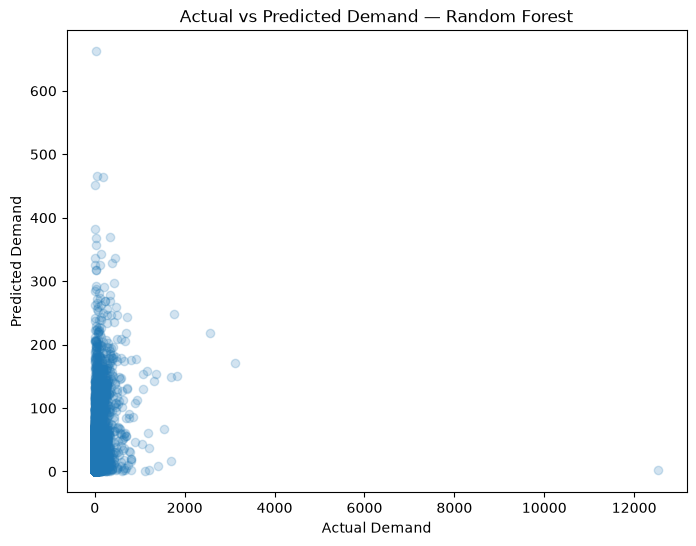

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.2
)

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted Demand — Random Forest")

plt.show()

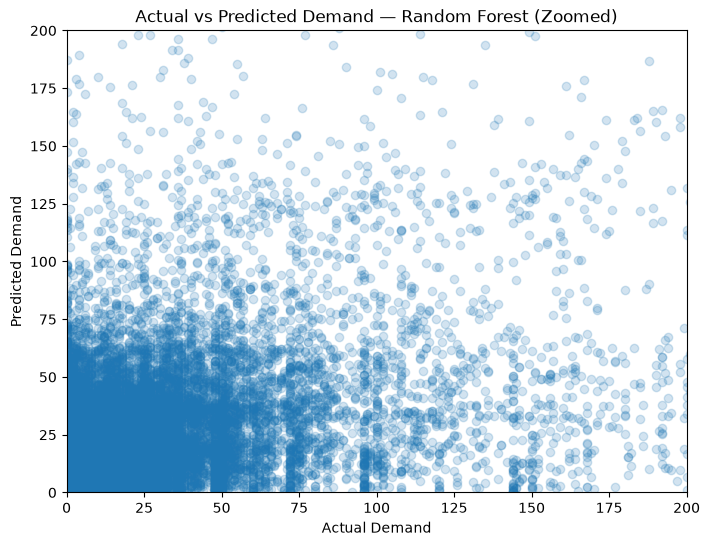

In [61]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.2
)

plt.xlim(0, 200)
plt.ylim(0, 200)

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted Demand — Random Forest (Zoomed)")

plt.show()

In [62]:
error_analysis = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_rf
})

error_analysis["Absolute_Error"] = (
    error_analysis["Actual"] - error_analysis["Predicted"]
).abs()

error_analysis["Demand_Range"] = pd.cut(
    error_analysis["Actual"],
    bins=[-1, 50, 75, 100, 125, 200, float("inf")],
    labels=["0–50", "51–75", "76–100", "101–125", "126–200", "200+"]
)

range_mae = (
    error_analysis
    .groupby("Demand_Range", observed=False)["Absolute_Error"]
    .mean()
    .reset_index()
)

print(range_mae)

  Demand_Range  Absolute_Error
0         0–50        6.323060
1        51–75       33.891406
2       76–100       50.647832
3      101–125       65.791595
4      126–200      102.668814
5         200+      329.719613


In [63]:
high_demand_counts = (
    error_analysis["Demand_Range"]
    .value_counts()
    .sort_index()
)

print(high_demand_counts)

Demand_Range
0–50       76182
51–75       1367
76–100       645
101–125      371
126–200      527
200+         468
Name: count, dtype: int64


In [64]:
high_demand_errors = (
    error_analysis[
        error_analysis["Actual"] > 200
    ]
    .sort_values("Absolute_Error", ascending=False)
)

print(
    high_demand_errors[
        ["Actual", "Predicted", "Absolute_Error"]
    ].head(10)
)

        Actual   Predicted  Absolute_Error
61669  12540.0    2.915747    12537.084253
22032   3111.0  170.297218     2940.702782
43668   2565.0  218.788615     2346.211385
79482   1686.0   16.144407     1669.855593
43676   1819.0  150.742786     1668.257214
43654   1697.0  148.511009     1548.488991
22008   1767.0  247.590728     1519.409272
56928   1534.0   66.226071     1467.773929
26978   1404.0    9.237807     1394.762193
22026   1369.0  153.559191     1215.440809


In [65]:
top_error = (
    error_analysis
    .sort_values("Absolute_Error", ascending=False)
    .head(1)
)

top_index = top_error.index[0]

print(
    test_data.loc[
        top_index,
        ["StockCode", "Date", "Demand", "Lag_1", "Lag_7", "Rolling_Mean_7"]
    ]
)

KeyError: np.int64(61669)

In [66]:
top_position = error_analysis["Absolute_Error"].idxmax()

print(
    test_data.iloc[
        top_position
    ][
        ["StockCode", "Date", "Demand", "Lag_1", "Lag_7", "Rolling_Mean_7"]
    ]
)

StockCode                       84826
Date              2011-11-25 00:00:00
Demand                        12540.0
Lag_1                             0.0
Lag_7                             0.0
Rolling_Mean_7                    0.0
Name: 753481, dtype: object


In [68]:
sales_clean[
    sales_clean["StockCode"] == "84826"
][
    ["InvoiceNo", "StockCode", "Description", "Quantity", "InvoiceDate", "CustomerID", "Country"]
].sort_values("InvoiceDate").tail(30)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,CustomerID,Country


In [69]:
print(sales_clean["StockCode"].dtype)

print(
    sales_clean[
        sales_clean["StockCode"].astype(str).str.strip() == "84826"
    ][
        ["InvoiceNo", "StockCode", "Description", "Quantity",
         "InvoiceDate", "CustomerID", "Country"]
    ].sort_values("InvoiceDate").tail(30)
)

object
       InvoiceNo StockCode                     Description  Quantity  \
37621     539472     84826  ASSTD DESIGN 3D PAPER STICKERS         2   
37613     539472     84826  ASSTD DESIGN 3D PAPER STICKERS         1   
41236     539761     84826  ASSTD DESIGN 3D PAPER STICKERS        60   
43760     540122     84826  ASSTD DESIGN 3D PAPER STICKERS        60   
47846     540420     84826  ASSTD DESIGN 3D PAPER STICKERS       120   
47982     540458     84826  ASSTD DESIGN 3D PAPER STICKERS        60   
48849     540477     84826  ASSTD DESIGN 3D PAPER STICKERS        60   
50969     540595     84826  ASSTD DESIGN 3D PAPER STICKERS        60   
64181     541594     84826  ASSTD DESIGN 3D PAPER STICKERS        60   
71478     542131     84826  ASSTD DESIGN 3D PAPER STICKERS        60   
88844     543820     84826  ASSTD DESIGN 3D PAPER STICKERS         6   
89638     543915     84826  ASSTD DESIGN 3D PAPER STICKERS        60   
113099    545909     84826  ASSTD DESIGN 3D PAPER STICKER

In [70]:
sales_clean[
    (sales_clean["StockCode"].astype(str).str.strip() == "84826") &
    (sales_clean["InvoiceNo"].astype(str) == "578841")
][
    ["InvoiceNo", "StockCode", "Description", "Quantity",
     "InvoiceDate", "UnitPrice", "CustomerID", "Country"]
]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
502122,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,2011-11-25 15:57:00,0.0,13256.0,United Kingdom


In [71]:
sales_clean[
    (sales_clean["InvoiceNo"].astype(str) == "578841") &
    (sales_clean["CustomerID"] == 13256)
][
    ["InvoiceNo", "StockCode", "Description", "Quantity",
     "UnitPrice", "CustomerID", "Country"]
]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country
502122,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,0.0,13256.0,United Kingdom


In [72]:
spike_index = error_analysis["Actual"].idxmax()

evaluation_without_spike = error_analysis.drop(index=spike_index)

mae_without_spike = evaluation_without_spike["Absolute_Error"].mean()

rmse_without_spike = (
    (
        evaluation_without_spike["Actual"]
        - evaluation_without_spike["Predicted"]
    ) ** 2
).mean() ** 0.5

print("Original MAE :", error_analysis["Absolute_Error"].mean())
print("Without spike MAE :", mae_without_spike)

print("Original RMSE :", (
    (error_analysis["Actual"] - error_analysis["Predicted"]) ** 2
).mean() ** 0.5)

print("Without spike RMSE :", rmse_without_spike)

Original MAE : 9.973915090523711
Without spike MAE : 9.816458230355519
Original RMSE : 57.81084900288314
Without spike RMSE : 36.96639874631558


In [73]:
print("Model:", rf_model)
print("Features:", features)

Model: RandomForestRegressor(max_depth=12, n_estimators=50, n_jobs=-1, random_state=42)
Features: ['Lag_1', 'Lag_7', 'Rolling_Mean_7', 'DayOfWeek', 'Month']


In [74]:
prediction_example = test_data.iloc[0]

print(prediction_example[
    ["StockCode", "Date", "Demand",
     "Lag_1", "Lag_7", "Rolling_Mean_7",
     "DayOfWeek", "Month"]
])

StockCode                       10080
Date              2011-11-09 00:00:00
Demand                            0.0
Lag_1                             0.0
Lag_7                            24.0
Rolling_Mean_7               3.428571
DayOfWeek                           2
Month                              11
Name: 394, dtype: object


In [75]:
prediction_input = prediction_example[features].to_frame().T

predicted_demand = rf_model.predict(prediction_input)[0]

print("StockCode:", prediction_example["StockCode"])
print("Date:", prediction_example["Date"])
print("Predicted Demand:", predicted_demand)
print("Actual Demand:", prediction_example["Demand"])

StockCode: 10080
Date: 2011-11-09 00:00:00
Predicted Demand: 4.529772438691739
Actual Demand: 0.0


In [76]:
prediction_results = test_data[
    ["StockCode", "Date", "Demand"]
].copy()

prediction_results["Predicted_Demand"] = y_pred_rf

prediction_results.head(10)

,StockCode,Date,Demand,Predicted_Demand
394,10080,2011-11-09,0.0,4.529772
395,10080,2011-11-10,22.0,1.311207
396,10080,2011-11-11,24.0,5.772278
397,10080,2011-11-12,0.0,0.000000
398,10080,2011-11-13,0.0,7.707165
399,10080,2011-11-14,12.0,5.958888
400,10080,2011-11-15,0.0,13.301063
401,10080,2011-11-16,0.0,10.578746
402,10080,2011-11-17,0.0,15.336182
403,10080,2011-11-18,4.0,7.617712


In [77]:
top_error = error_analysis.loc[
    error_analysis["Absolute_Error"].idxmax()
]

print(top_error)

Actual                 12540.0
Predicted             2.915747
Absolute_Error    12537.084253
Demand_Range              200+
Name: 61669, dtype: object


In [78]:
spike_index = error_analysis["Absolute_Error"].idxmax()

print(
    test_data.iloc[spike_index][
        ["StockCode", "Date", "Demand",
         "Lag_1", "Lag_7", "Rolling_Mean_7"]
    ]
)

StockCode                       84826
Date              2011-11-25 00:00:00
Demand                        12540.0
Lag_1                             0.0
Lag_7                             0.0
Rolling_Mean_7                    0.0
Name: 753481, dtype: object


In [79]:
sales_clean[
    sales_clean["StockCode"].astype(str).str.strip() == "84826"
][
    ["InvoiceNo", "StockCode", "Description", "Quantity",
     "InvoiceDate", "CustomerID", "Country"]
].sort_values("InvoiceDate").tail(30)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,CustomerID,Country
37621,539472,84826,ASSTD DESIGN 3D PAPER STICKERS,2,2010-12-19 14:23:00,15581.0,United Kingdom
37613,539472,84826,ASSTD DESIGN 3D PAPER STICKERS,1,2010-12-19 14:23:00,15581.0,United Kingdom
41236,539761,84826,ASSTD DESIGN 3D PAPER STICKERS,60,2010-12-22 10:29:00,17593.0,United Kingdom
43760,540122,84826,ASSTD DESIGN 3D PAPER STICKERS,60,2011-01-05 10:39:00,13694.0,United Kingdom
47846,540420,84826,ASSTD DESIGN 3D PAPER STICKERS,120,2011-01-07 11:13:00,12829.0,United Kingdom
47982,540458,84826,ASSTD DESIGN 3D PAPER STICKERS,60,2011-01-07 12:28:00,12501.0,Germany
48849,540477,84826,ASSTD DESIGN 3D PAPER STICKERS,60,2011-01-07 14:49:00,13233.0,United Kingdom
50969,540595,84826,ASSTD DESIGN 3D PAPER STICKERS,60,2011-01-10 11:35:00,14321.0,United Kingdom
64181,541594,84826,ASSTD DESIGN 3D PAPER STICKERS,60,2011-01-19 15:30:00,14916.0,United Kingdom
71478,542131,84826,ASSTD DESIGN 3D PAPER STICKERS,60,2011-01-25 15:55:00,16133.0,United Kingdom


In [80]:
sales_clean[
    (sales_clean["InvoiceNo"].astype(str) == "578841") &
    (sales_clean["CustomerID"] == 13256)
][
    ["InvoiceNo", "StockCode", "Description",
     "Quantity", "UnitPrice", "CustomerID", "Country"]
]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country
502122,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,0.0,13256.0,United Kingdom


In [81]:
prediction_results.head(10)

,StockCode,Date,Demand,Predicted_Demand
394,10080,2011-11-09,0.0,4.529772
395,10080,2011-11-10,22.0,1.311207
396,10080,2011-11-11,24.0,5.772278
397,10080,2011-11-12,0.0,0.000000
398,10080,2011-11-13,0.0,7.707165
399,10080,2011-11-14,12.0,5.958888
400,10080,2011-11-15,0.0,13.301063
401,10080,2011-11-16,0.0,10.578746
402,10080,2011-11-17,0.0,15.336182
403,10080,2011-11-18,4.0,7.617712


In [82]:
print("Prediction columns:")
print(prediction_results.columns.tolist())

Prediction columns:
['StockCode', 'Date', 'Demand', 'Predicted_Demand']


In [83]:
prediction_results["Error"] = (
    prediction_results["Demand"]
    - prediction_results["Predicted_Demand"]
)

prediction_results.head(10)

,StockCode,Date,Demand,Predicted_Demand,Error
394,10080,2011-11-09,0.0,4.529772,-4.529772
395,10080,2011-11-10,22.0,1.311207,20.688793
396,10080,2011-11-11,24.0,5.772278,18.227722
397,10080,2011-11-12,0.0,0.000000,0.000000
398,10080,2011-11-13,0.0,7.707165,-7.707165
399,10080,2011-11-14,12.0,5.958888,6.041112
400,10080,2011-11-15,0.0,13.301063,-13.301063
401,10080,2011-11-16,0.0,10.578746,-10.578746
402,10080,2011-11-17,0.0,15.336182,-15.336182
403,10080,2011-11-18,4.0,7.617712,-3.617712


In [86]:
inventory_columns = [
    "id",
    "title",
    "stock",
    "availabilityStatus",
    "minimumOrderQuantity",
    "is_low_stock",
    "is_out_of_stock",
    "stock_level"
]

df[inventory_columns].head(10)

NameError: name 'df' is not defined

In [85]:
import pandas as pd

print("Pandas imported successfully")

Pandas imported successfully


In [88]:
df = pd.read_json("../data/products.json")

print("API data loaded successfully")
print("Shape:", df.shape)

FileNotFoundError: File ../data/products.json does not exist

In [89]:
import os

print(os.getcwd())

D:\Projects-Pub\Python_Projects\Real-Time-Ecommerce-Data-Science-Project\notebooks


In [90]:
import os

print(os.listdir("../data"))

['Online Retail.xlsx', 'raw']


In [91]:
import os

print(os.listdir("../data/raw"))

[]


In [92]:
import pandas as pd

url = "https://dummyjson.com/products"
api_data = pd.read_json(url)

print(api_data.shape)

FileNotFoundError: File https://dummyjson.com/products does not exist

In [93]:
import requests

url = "https://dummyjson.com/products"

response = requests.get(url)

print(response.status_code)

200


In [94]:
data = response.json()

print(data.keys())

dict_keys(['products', 'total', 'skip', 'limit'])


In [95]:
df = pd.DataFrame(data["products"])

print(df.shape)

(30, 22)


In [98]:
inventory_columns = [
    "id",
    "title",
    "stock",
    "availabilityStatus",
    "minimumOrderQuantity"
]

df[inventory_columns].head(10)

,id,title,stock,availabilityStatus,minimumOrderQuantity
0,1,Essence Mascara Lash Princess,99,In Stock,48
1,2,Eyeshadow Palette with Mirror,34,In Stock,20
2,3,Powder Canister,89,In Stock,22
3,4,Red Lipstick,91,In Stock,40
4,5,Red Nail Polish,79,In Stock,22
5,6,Calvin Klein CK One,29,In Stock,9
6,7,Chanel Coco Noir Eau De,58,In Stock,1
7,8,Dior J'adore,98,In Stock,10
8,9,Dolce Shine Eau de,4,Low Stock,2
9,10,Gucci Bloom Eau de,91,In Stock,2


In [99]:
print("API product IDs:")
print(df["id"].head(10).tolist())

print("\nHistorical StockCodes:")
print(daily_demand["StockCode"].head(10).tolist())

API product IDs:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

Historical StockCodes:
[10002, 10002, 10002, 10002, 10002, 10002, 10002, 10002, 10002, 10002]


In [100]:
print("Current API products:", len(df))
print("API total products:", data["total"])

Current API products: 30
API total products: 194


In [101]:
prediction_results["Error"] = (
    prediction_results["Actual Demand"]
    - prediction_results["Predicted_Demand"]
)

prediction_results.head()

KeyError: 'Actual Demand'

In [102]:
prediction_results.columns.tolist()

['StockCode', 'Date', 'Demand', 'Predicted_Demand', 'Error']